# Chemical Reaction Engineering III / Assignment 2
Group 5: Aleyna Bolcu, Maximilian Franz, Peter Schönung

All group members equally contributed to the report.

## Task
* research required information, e.g. meaningful reaction conditions, thermodynamic data, data for validation
* brief discussion of the mathematical approach and the implementation to Python
* verification of the implementation with a meaningful strategy
* scientific discussion of the results
* derivation of conclusions, e.g. on design and operation of suitable reactors with brief comparison to industrial practice

The assignment involves several key steps:

**1.** Introduction and Objective

> > **1.1.** Yield

> > **1.2.** Reaction Extend

**2.** Importing the Reserached Glenn Data-Sets

**3.** Stoichiometric Matrix and Determination of Key Reactions

> > **3.1.** Formulating the Matrix of Stoichiometric Coefficients

> > **3.2.** Stoichiometric Network Analysis and Rank Verification

> > **3.4.** Mathematical Independence and Matrix Rank

> > **3.5.** Partitioning the Stoichiometric Matrix

**4.** Thermodynamic Functions (NASA Glenn Equations)

> > **4.1.** Coding the NASA-Glenn-equations

> > **4.2.** Validating the Programmed Formulas with NIST-JANAF Literature Data

> > **4.3.** Visualizing the Values for $c_p(T)$, $H°(T)$ and $S(T)$

> > **4.4.** Calculating Reaction Enthalpy, Entropy, and Gibbs Free Energy

> > **4.5.** Literature Reference Values for Equilibrium Constants

> > **4.6.** Visualizing the Values for $\Delta_{R}H(T)$, $\Delta_{R}S(T)$ and $\Delta_{R}G(T)$

**5.** Determination of the Reaction Extents ($\xi$) from Equilibrium Constants ($K_x$)

> > **5.1.** Visualizing the Reaction Extent ($\xi$) as a Function of Temperature, Pressure, and Inlet Concentration

**6.** Three Dimensional Analysis of the Reaction Network

> > **6.1.** Interactive Point-by-Point Thermodynamic Analysis

> > **6.2.** Interactive 3D Mapping Across All Test Cases

**7.** Calculation of the Yield

> > **7.1.** Interactive 3D Surface Mapping of the DME Yield

**8.** Discussion of Results

**9.** AI Use and Reflection

**10.** References


# 1. Introduction and Objective

The primary objective of this assignment is to investigate the equilibrium yield of dimethyl ether (DME, $CH_3OCH_3$) during DME synthesis. During the process of DME synthesis, a syngas consisiting of mostly $\mathrm{CO}$, $\mathrm{CO}_2$ and $\mathrm{H}_2$ is used for the inlet stream. Over a system of reversible reactions, this inlet stream is converted to methanol and from methanol to DME:

1. **Methanol synthesis from $CO_2$:**
   $$\text{CO}_2 + 3\text{H}_2 \rightleftharpoons \text{CH}_3\text{OH} + \text{H}_2\text{O} \tag{1}$$

2. **Methanol synthesis from $CO$:**
   $$\text{CO} + 2\text{H}_2 \rightleftharpoons \text{CH}_3\text{OH} \tag{2}$$

3. **Reverse Water-Gas Shift reaction:**
   $$\text{CO}_2 + \text{H}_2 \rightleftharpoons \text{CO} + \text{H}_2\text{O} \tag{2}$$

4. **Methanol dehydration to DME:**
   $$2\text{CH}_3\text{OH} \rightleftharpoons \text{CH}_3\text{OCH}_3 + \text{H}_2\text{O} \tag{3}$$

Because of the utilization of $\mathrm{CO}$, $\mathrm{CO}_2$ and $\mathrm{H}_2$ as a feedstock, the process has gained increased attention due to its possible use in a "green" economy. $\mathrm{H}_2$ can be sources from renewable energy driven processes, while $\mathrm{CO}_2$ is bound to be captured from industrial waste gas or the atmosphere directly in the fight against climate change. DME presents an alternative source as a fuel of chemical feedstock, making it an attractive target in the transition of the industry. Maximizing the efficiency of this process is therefor an important target.

To meet this goal, understanding the equilibrium yield is a fundamental step in chemical reaction engineering, as it defines the ultimate thermodynamic limits of the system before considering kinetic limitations. No matter the optimization of reactor or raction conditions, the equillibrium yield for a given Temperature and pressure represents the thermodynamical upper limit of conversion into the desired product. Therefore, in this study, the equilibrium composition and DME yield are analyzed as a function of the key process variables: temperature ($T$), pressure ($p$) and inlet composition. 

Our approach uses a matrix based deduction of relevant key reactions in the reaction network, to narrow the relevant parameters down. With this focused approach, we use a numerical solution to calculate the reaction extend for each reaction and from that the equilbrium conditions for each case. The Data we use is taken from the NASA-Glenn data-sets, from which we can calculate the parameters $\mathrm{c}_{\mathrm{p}}$, $\mathrm{H}^\circ$ and $\mathrm{S}^\circ$. From these we calculate all consecutively needed thermodynamical data to get results for the equillibrium yield.

From our results, we aim to identify optimum operating windows that maximize DME yield. This analysis provides the thermodynamic framework necessary to evaluate feasibility before considering industrial kinetic limitations.

## 1.1. Yield

The yield ($Y_k$) specifically quantifies the efficiency of converting a target reactant ($i$) into the desired product ($k$). In practical terms, it defines the exact fraction of reactant $i$ that is successfully converted into product $k$. For our specific system, the primary reactants are $CO_2$ and $H_2$, while all other formed species are considered byproducts. Mathematically, it is defined as:

\begin{equation}
    Y_{k} = \frac{\nu_i}{\nu_k} \, \frac{n_{k, 0}-n_{k}}{n_{i,0}}
    \tag{4}
\end{equation}

- $Y_k$: Yield of product $k$
- $i$: Target reactant
- $k$: Desired product
- $\nu_i, \nu_k$: Stoichiometric coefficients
- $n_{k,0}$: Initial molar amount of species $k$
- $n_k$: Final molar amount of species $k$
- $n_{i,0}$: Initial molar amount of species $i$

## 1.2. Reaction extend

The reaction extent ($\xi$) is a macroscopic, component independent measure of how far a specific reaction has proceeded. It relates the change in the molar amount (or molar flow rate) of any component $i$ to its stoichiometric coefficient $\nu_i$:

\begin{equation}
    \xi_{i} = \frac{n_i - n_{i,0}}{\nu_i}
    \tag{5}
\end{equation}

- $\xi_i$: Reaction extent
- $n_i$: Current molar amount of species $i$
- $n_{i,0}$: Initial molar amount of species $i$
- $\nu_i$: Stoichiometric coefficient of species $i$
- $i$: Any chemical species/component

# 2. Importing the Researched Glenn Data-Sets

To perform accurate equilibrium calculations, robust thermodynamic data for all species involved in the DME synthesis ($CO_2$, $H_2$, $CH_3OH$, $H_2O$, $CO$, and $CH_3OCH_3$) is required. The NASA Glenn thermodynamic database was utilized to obtain the necessary Shomate equation coefficients [2].

A critical aspect of using NASA-Glenn equations is that the empirical coefficients are temperature-dependent and are typically split into two distinct temperature intervals ($T_1$ for lower ranges and $T_2$ for higher ranges) to maintain high precision. 


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as scp
import pandas as pd

# Pfad zu den Daten
data_path = r'c:\Users\Peter\Documents\Uni\Master\CRE 3\CRE3-Assignment-2\data_literature\NASA_glenn_coefficients_full.csv' # Windows Version
# data_path = r'/home/pit/Uni/Master/CRE3/CRE3-Assignment-2/data_literature/NASA_glenn_coefficients_full.csv' # Linux Version
# data_path = r"C:\Users\Franz\Documents\GitHub\CRE3-Assignment-2\data_literature\NASA_glenn_coefficients_full.csv"

# NASA Glenn Koeffizienten laden
df_nasa = pd.read_csv(data_path)
print("\nSpecies loaded:")
print(df_nasa[['species_name', 'formula', 'T1_min_K', 'T1_max_K', 'T2_min_K', 'T2_max_K']].to_string())


Species loaded:
  species_name  formula  T1_min_K  T1_max_K  T2_min_K  T2_max_K
0           H2       H2     200.0    1000.0    1000.0    6000.0
1          H2O      H2O     200.0    1000.0    1000.0    6000.0
2           CO       CO     200.0    1000.0    1000.0    6000.0
3          CO2      CO2     200.0    1000.0    1000.0    6000.0
4        CH3OH    CH3OH     200.0    1000.0    1000.0    6000.0
5      CH3OCH3  CH3OCH3     200.0    1000.0    1000.0    6000.0


# 3. Stoichiometric Matrix and Determination of Key Reactions

### 3.1. Formulating the Matrix of Stoichiometric Coefficients
First, the matrix of stoichiometric coefficients $\underline{N}$ was established, with reactions $R_j$ arranged in columns and components $A_i$ arranged in rows. The transposed matrix $\underline{N}^T$ for the DME synthesis network is thus defined as:
\begin{equation}
  \underline{N}^T=
    \begin{bmatrix}
    & CO & CO_2 & CH_3OCH_3 & H_2 & H_2O & CH_3OH \\
R_1 & 0 & -1 & 0 & -3 & 1 & 1 \\
R_2 & -1 & 0 & 0 & -2 & 0 & 1 \\
R_3 & 1 & -1 & 0 & -1 & 1 & 0 \\
R_4 & 0 & 0 & 1 & 0 & 1 & -2
    \end{bmatrix}
    \tag{6}
\end{equation}


### 3.2. Mathematical Independence and Matrix Rank
The rank of the matrix of stoichiometric coefficients $R_N$ gives the number of key components and reactions. As calculated below, the rank is $R_N = 3$. This result is physically consistent with the reaction network, as the four reactions initially identified are not linearly independent. Specifically, the third reaction ($R_3$) can be expressed as a linear combination of the first two ($R_1 - R_2 = R_3$).

To determine the reaction extent later, the overall stoichiometric matrix must be partitioned into submatrices. For this mathematical method to be applicable, the square submatrix representing the key reactions ($\underline{N}_{11}$) must be invertible. If the linearly dependent reaction $R_3$ is kept within this core submatrix, its determinant would be zero, making the mathematical solution impossible.

Therefore, reactions $R_4$ and $R_3$ are deliberately interchanged to establish a valid set of independent key reactions, enabling a successful solution of the mathematical approach:

\begin{equation}
  \underline{N}^T=
    \begin{bmatrix}
    & CO & CO_2 & CH_3OCH_3 & H_2 & H_2O & CH_3OH \\
R_1 & 0 & -1 & 0 & -3 & 1 & 1 \\
R_2 & -1 & 0 & 0 & -2 & 0 & 1 \\
R_4 & 0 & 0 & 1 & 0 & 1 & -2  \\
R_3 & 1 & -1 & 0 & -1 & 1 & 0 
    \end{bmatrix}
    \tag{7}
\end{equation}

In [2]:
from numpy.linalg import matrix_rank

# --- DME Synthesis Stoichiometric Analysis ---
# Component Order: [CO, CO2, CH3OCH3 (DME), H2, H2O, CH3OH]
# Reaction Order adjusted: [R1, R2, R4, R3] to ensure N11 is non-singular
# This order ensures Key Components are in the first 3 rows (Rank = 3)

n_matrix = np.array([
    [ 0, -1,  0,  1],  # CO    
    [-1,  0,  0, -1],  # CO2   
    [ 0,  0,  1,  0],  # CH3OCH3 (DME) -> Now independent in the 3rd column (because R1-R2=R3)
    [-3, -2,  0, -1],  # H2    
    [ 1,  0,  1,  1],  # H2O   
    [ 1,  1, -2,  0]   # CH3OH
])

# Get the transposed matrix (N^T)
n_transposed = n_matrix.T

# Determine the rank of the matrix
n_rank = matrix_rank(n_matrix)

print("--- DME Synthesis Stoichiometric Analysis ---")
print(f"Sequence: [CO, CO2, CH3OCH3 (DME), H2, H2O, CH3OH]")
print("\nTransposed Matrix (N^T):")
print(n_transposed)
print(f"\nMatrix Rank (Number of Key Reactions): {n_rank}")

# creating a list of species and their corresponding indexes in the transposed matrix/reactions 1-4
# Index 0 = R1, Index 1 = R2, Index 2 = R4, Index 3 = R3 (adjusted order for independence)
species = ['CO', 'CO2', 'CH3OCH3', 'H2', 'H2O', 'CH3OH']
reaction_tuples = np.full((len(n_transposed), len(species)), '', dtype=object)

for i in range(4):
    for j in range(len(species)):
        reaction_tuples[i][j] = (species[j], n_transposed[i][j])

--- DME Synthesis Stoichiometric Analysis ---
Sequence: [CO, CO2, CH3OCH3 (DME), H2, H2O, CH3OH]

Transposed Matrix (N^T):
[[ 0 -1  0 -3  1  1]
 [-1  0  0 -2  0  1]
 [ 0  0  1  0  1 -2]
 [ 1 -1  0 -1  1  0]]

Matrix Rank (Number of Key Reactions): 3


The rank is $R_N=3$, which means that three key reactions and components are sufficient to describe the reaction extent based on stoichiometry. According to the order of components and reactions chosen for the matrix of stoichiometric coefficients, $CO$, $CO_2$, $CH_3OCH_3 (DME)$ are the key components. 

### 3.2. Stoichiometric Network Analysis and Rank Verification
To address the requirement of verifying the linear independence of the reaction set, a formal rank analysis was conducted. This control procedure was implemented to ensure that the selected reaction network is numerically stable and does not contain overlapping constraints.

The stoichiometric matrix $\underline{N}$ is constructed where columns represent the chosen reactions and rows represent the species coefficients.
| Species | R1 | R2 | R4 |
| :--- | :---: | :---: | :---: |
| $CO_2$ | -1 | 0 | 0 |
| $H_2$ | -3 | -2 | 0 |
| $CO$ | 0 | -1 | 0 |
| $CH_3OH$ | 1 | 1 | -2 |
| $H_2O$ | 1 | 0 | 1 |
| $CH_3OCH_3$ | 0 | 0 | 1 |

The following code defines the matrix and verifies its rank. This check confirms that the chosen reaction set is linearly independent and provides a robust basis for numerical equilibrium calculations.

In [3]:
# Define the stoichiometric matrix N
# Rows: [CO2, H2, CO, CH3OH, H2O, CH3OCH3]
# Columns: [R1, R2, R4]
N = np.array([
    [-1,  0,  0],  # CO2
    [-3, -2,  0],  # H2
    [ 0, -1,  0],  # CO
    [ 1,  1, -2],  # CH3OH
    [ 1,  0,  1],  # H2O
    [ 0,  0,  1]   # CH3OCH3
])

# Calculate and print the rank of the matrix
# As per the assignment requirement, the rank is checked to ensure 
# the chosen set of key reactions is linearly independent.
rank = np.linalg.matrix_rank(N)
print(f"Rank of the stoichiometric matrix: {rank}")

if rank == N.shape[1]:
    print("Verification successful: The reaction set is linearly independent.")
else:
    print("Warning: The reaction set contains linearly dependent reactions.")

Rank of the stoichiometric matrix: 3
Verification successful: The reaction set is linearly independent.


## 4. Thermodynamic Functions (NASA Glenn Equations)

To model the temperature dependence of the thermodynamic properties with high precision, the NASA Glenn polynomial format was utilized. For each species and defined temperature range, 7 primary coefficients ($a_1$ to $a_7$) and 2 integration constants ($b_1$ and $b_2$) are used to calculate the dimensionless heat capacity, enthalpy, and entropy:

$$\frac{C_p^\circ(T)}{R} = a_1 T^{-2} + a_2 T^{-1} + a_3 + a_4 T + a_5 T^2 + a_6 T^3 + a_7 T^4 \tag{8}$$

$$\frac{H^\circ(T)}{RT} = -a_1 T^{-2} + a_2 \frac{\ln T}{T} + a_3 + \frac{a_4}{2} T + \frac{a_5}{3} T^2 + \frac{a_6}{4} T^3 + \frac{a_7}{5} T^4 + \frac{b_1}{T} \tag{9}$$

$$\frac{S^\circ(T)}{R} = -\frac{a_1}{2} T^{-2} - a_2 T^{-1} + a_3 \ln T + a_4 T + \frac{a_5}{2} T^2 + \frac{a_6}{3} T^3 + \frac{a_7}{4} T^4 + b_2 \tag{10}$$

where:
- $C_p^\circ(T)$ = standard heat capacity $\left[\mathrm{J\,mol^{-1}\,K^{-1}}\right]$
- $H^\circ(T)$ = standard enthalpy $\left[\mathrm{J\,mol^{-1}}\right]$
- $S^\circ(T)$ = standard entropy $\left[\mathrm{J\,mol^{-1}\,K^{-1}}\right]$
- $R$ = universal gas constant $\left[\mathrm{J\,mol^{-1}\,K^{-1}}\right]$
- $T$ = temperature $\left[\mathrm{K}\right]$
- $a_1,\dots,a_7$ = NASA Glenn temperature coefficients
- $b_1, b_2$ = integration constants

From a reaction engineering perspective, these equations are strictly interconnected. The equation for standard enthalpy ($H^\circ$) is mathematically derived by integrating the specific heat capacity polynomial ($\int C_p^\circ \, dT$), which introduces the first integration constant $b_1$. Similarly, the standard entropy ($S^\circ$) is derived via $\int \frac{C_p^\circ}{T} \, dT$, introducing the second integration constant $b_2$.



In [4]:
# Storing Glenn-coefficients in Dictionary
# This code cell does not calculate the thermodynamic properties, but rather organizes the NASA Glenn coefficients into a dictionary for easy access in later calculations.

GLENN_NASA = {}

for _, row in df_nasa.iterrows():
    species = row['species_name'].strip()
    # Checks, if the given row has only one or two temperature ranges. If T2_min_K is NaN, there is only one range.
    if pd.isna(row['T2_min_K']): 
        # Only one Temperature range
        ranges = [(
            row['T1_min_K'], row['T1_max_K'],
            row['a1_T1'], row['a2_T1'], row['a3_T1'], row['a4_T1'], row['a5_T1'],
            row['a6_T1'], row['a7_T1'], row['b1_T1'], row['b2_T1']
        )]
    else:
        # Two temperature ranges
        ranges = [
            (
                row['T1_min_K'], row['T1_max_K'],
                row['a1_T1'], row['a2_T1'], row['a3_T1'], row['a4_T1'], row['a5_T1'],
                row['a6_T1'], row['a7_T1'], row['b1_T1'], row['b2_T1']
            )
        ]
        # Additional check to ensure that the second range is valid before appending
        if not pd.isna(row['T2_min_K']):
            ranges.append((
                row['T2_min_K'], row['T2_max_K'],
                row['a1_T2'], row['a2_T2'], row['a3_T2'], row['a4_T2'], row['a5_T2'],
                row['a6_T2'], row['a7_T2'], row['b1_T2'], row['b2_T2']
            ))
    GLENN_NASA[species] = ranges

# getting the enthalpy of formation at 298 K for a given species:
def get_hf298(species):
    dict_species = df_nasa.set_index('species_name')
    return dict_species.loc[species]['hf298_J_mol']



## 4.1. Coding the NASA-Glenn-equations
To enable the practical evaluation of the NASA Glenn polynomial expressions, a thermodynamic framework was established for the temperature-dependent calculation of the specific heat capacity, standard enthalpy, and standard entropy of each species. The functions defined below enable us to evaluate these properties for different Temperatures on demand in later calculations.

An important feature of this implementation is the automated temperature interval validation. The functions dynamically select the correct low or high temperature polynomial parameters given from the glenn data sets based on the system's current conditions, inherently preventing thermodynamic extrapolation errors.

Additionally, to get the themodynamic data from the calculations, we need to multiply them with the universal gas constant ($R = 8.314 \text{ J/(mol}\cdot\text{K)}$) and the Temperature in K according to the above formulated equations, to yield absolute thermodynamic properties in standard engineering units.

In [5]:
R = 8.314  # J/(mol*K)

def cp_T(species, T):
    """
    Calculate the specific heat capacity (Cp) at a given temperature T for a specified species.
    
    Parameters:
    - species: The name of the species (string).
    - T: Temperature in Kelvin (float).
    
    Returns:
    - Cp: Specific heat capacity in J/(mol*K) (float).
    """
    if species not in GLENN_NASA:
        raise ValueError(f"Species '{species}' not found in GLENN_NASA data.")
    
    # Find the correct temperature range for the given species
    for r in GLENN_NASA[species]:
        T_min, T_max = r[0], r[1]
        if T_min <= T <= T_max:
            a1, a2, a3, a4, a5, a6, a7, b1, b2 = r[2], r[3], r[4], r[5], r[6], r[7], r[8], r[9], r[10]
            # Calculate Cp using the NASA polynomial coefficients
            Cp = R * (a1 * T**(-2) + a2 * T**(-1) + a3 + a4 * T + a5 * T**2 + a6 * T**3 + a7 * T**4)
            return Cp
    
    raise ValueError(f"Temperature {T} K is out of range for species '{species}'.")

def hf_T(species, T):
    """
    Calculate the enthalpy of formation (hf) at a given temperature T for a specified species.
    
    Parameters:
    - species: The name of the species (string).
    - T: Temperature in Kelvin (float).
    
    Returns:
    - hf: Enthalpy of formation in J/mol (float).
    """
    if species not in GLENN_NASA:
        raise ValueError(f"Species '{species}' not found in GLENN_NASA data.")
    
    # Find the correct temperature range for the given species
    for r in GLENN_NASA[species]:
        T_min, T_max = r[0], r[1]
        if T_min <= T <= T_max:
            a1, a2, a3, a4, a5, a6, a7, b1, b2 = r[2], r[3], r[4], r[5], r[6], r[7], r[8], r[9], r[10]
            # Calculate the change in enthalpy from 298 K to T using the NASA polynomial coefficients
            # IMPORTANT: The NASA polynomials give the specific heat capacity (Cp) as a function of temperature. To get the enthalpy at temperature T, we need to integrate Cp from 298 K to T and add the enthalpy of formation at 298 K (hf298).
            # The addition of hf298 is already included in the coefficient b1, which is the constant term in the enthalpy polynomial. Therefore, we can directly use the polynomial to calculate the enthalpy at temperature T.
            delta_hf = R * T * ((-a1 * T**(-2)) + a2 * (np.log(T)/T) + a3 + (a4/2) * T + (a5/3) * T**2 + (a6/4) * T**3 + (a7/5) * T**4 + b1/T )
            return delta_hf
    
    raise ValueError(f"Temperature {T} K is out of range for species '{species}'.")

def s_T(species, T):
    """
    Calculate the entropy (S) at a given temperature T for a specified species.
    
    Parameters:
    - species: The name of the species (string).
    - T: Temperature in Kelvin (float).
    
    Returns:
    - S: Entropy in J/(mol*K) (float).
    """
    if species not in GLENN_NASA:
        raise ValueError(f"Species '{species}' not found in GLENN_NASA data.")
    
    # Find the correct temperature range for the given species
    for r in GLENN_NASA[species]:
        T_min, T_max = r[0], r[1]
        if T_min <= T <= T_max:
            a1, a2, a3, a4, a5, a6, a7, b1, b2 = r[2], r[3], r[4], r[5], r[6], r[7], r[8], r[9], r[10]
            # Calculate S using the NASA polynomial coefficients
            S = R * ((-(a1/2) * T**(-2)) - a2 * T**(-1) + a3 * np.log(T) + a4 * T + (a5/2) * T**2 + (a6/3) * T**3 + (a7/4) * T**4 + b2)
            return S
    
    raise ValueError(f"Temperature {T} K is out of range for species '{species}'.")

print("\n--- Thermodynamic Properties Calculation ---")
# Validation values for Temperatures 298,15 K, 500 K, 1000 K, printed as a table for readability
validation_temperatures = [298.15, 500, 1000]
validation_species = ['CO', 'CO2', 'CH3OCH3', 'H2', 'H2O', 'CH3OH']
print(f"{'Species':<10} {'T (K)':<10} {'Cp (J/mol*K)':<20} {'H°-H°(298.15 K) (kJ/mol)':<28} {'S (J/mol*K)':<20}")
for T in validation_temperatures:
    print("-" * 80)
    for sp in validation_species:
        cp_value = cp_T(sp, T)
        hf_value = (hf_T(sp, T)-get_hf298(sp)) / 1000  # Convert to kJ/mol
        s_value = s_T(sp, T)
        print(f"{sp:<10} {T:<10.2f} {cp_value:<20.2f} {hf_value:<28f} {s_value:<20.2f}")


--- Thermodynamic Properties Calculation ---
Species    T (K)      Cp (J/mol*K)         H°-H°(298.15 K) (kJ/mol)     S (J/mol*K)         
--------------------------------------------------------------------------------
CO         298.15     29.14                0.006780                     197.65              
CO2        298.15     37.13                0.024137                     213.77              
CH3OCH3    298.15     65.82                0.011293                     267.36              
H2         298.15     28.83                -0.000000                    130.67              
H2O        298.15     33.59                0.014833                     188.82              
CH3OH      298.15     44.04                0.012325                     239.80              
--------------------------------------------------------------------------------
CO         500.00     29.79                5.937225                     212.82              
CO2        500.00     44.62                8.330

## 4.2. Validating the Programmed Formulas with NIST-JANAF Literature Data

To ensure the reliability of the reaction engineering model, it is imperative to validate the programmed thermodynamic functions against established standard literature before proceeding to the complex equilibrium solver. For this purpose, the computational results at three distinct operating temperatures (298.15 K, 500 K, and 1000 K) were compared against the standard data from the NIST-JANAF Thermochemical Tables [3].  

The reference literature values for the specific heat capacity ($C_p^\circ$), sensible enthalpy change ($H^\circ_T - H^\circ_{298.15}$), and standard entropy ($S^\circ$) are provided in the table below. 

A direct comparison between the Python solver output and the JANAF reference data reveals an excellent agreement across all components and temperature ranges. The negligible deviations observed are to be expected; they represent the inherent, acceptable statistical variance caused by the regression nature of the NASA Glenn polynomial curve fits. 

This successful validation confirms that the implemented thermodynamic baseline is mathematically robust and physically accurate, allowing us to confidently utilize these discrete variables to calculate the standard Gibbs free energy ($\Delta_R G^\circ$) and the equilibrium constants ($K_{eq}$) for the DME synthesis network.

#### Standard Thermodynamic Reference Data (Ideal Gas, $p^\circ = 0.1 \text{ MPa}$) [3]

| Spezies | T (K) | Cp° (J·mol⁻¹·K⁻¹) | H°−H°(298.15) (kJ·mol⁻¹) | S° (J·mol⁻¹·K⁻¹) | log Kf (−) |
|---------|-------|--------------------|--------------------------|-------------------|------------|
| CO      | 298.15 | 29.142            | 0.000                    | 197.653           | 24.030     |
| CO₂     | 298.15 | 37.129            | 0.000                    | 213.795           | 69.095     |
| H₂      | 298.15 | 28.836            | 0.000                    | 130.680           | 0.000      |
| H₂O(g)  | 298.15 | 33.590            | 0.000                    | 188.834           | 40.047     |
| CH₃OH(g)| 298.15 | 44.06             | 0.000                    | 239.9             | 28.44 *    |
|||||||
| CO      | 500    | 29.794            | 5.931                    | 212.831           | 16.236     |
| CO₂     | 500    | 44.627            | 8.305                    | 234.901           | 41.259     |
| H₂      | 500    | 29.260            | 5.882                    | 145.737           | 0.000      |
| H₂O(g)  | 500    | 35.226            | 6.925                    | 206.534           | 22.884     |
| CH₃OH(g)| 500    | —                 | —                        | —                 | —          |
|||||||
| CO      | 1000   | 33.183            | 21.690                   | 234.538           | 10.461     |
| CO₂     | 1000   | 54.308            | 33.397                   | 269.299           | 20.679     |
| H₂      | 1000   | 30.205            | 20.680                   | 166.216           | 0.000      |
| H₂O(g)  | 1000   | 41.268            | 26.000                   | 232.738           | 10.060     |
| CH₃OH(g)| 1000   | —                 | —                        | —                 | —          |


## 4.3. Visualizing the Values for $c_p(T)$, $H°(T)$ and $S(T)$
While discrete validation at specific temperatures is necessary, understanding the continuous thermodynamic behavior of the reaction network across a broad operational window (250 K to 2000 K) is crucial. To achieve this, the verified thermodynamic functions are evaluated over a dense temperature grid, generating the profiles for heat capacity, standard enthalpy, and standard entropy.

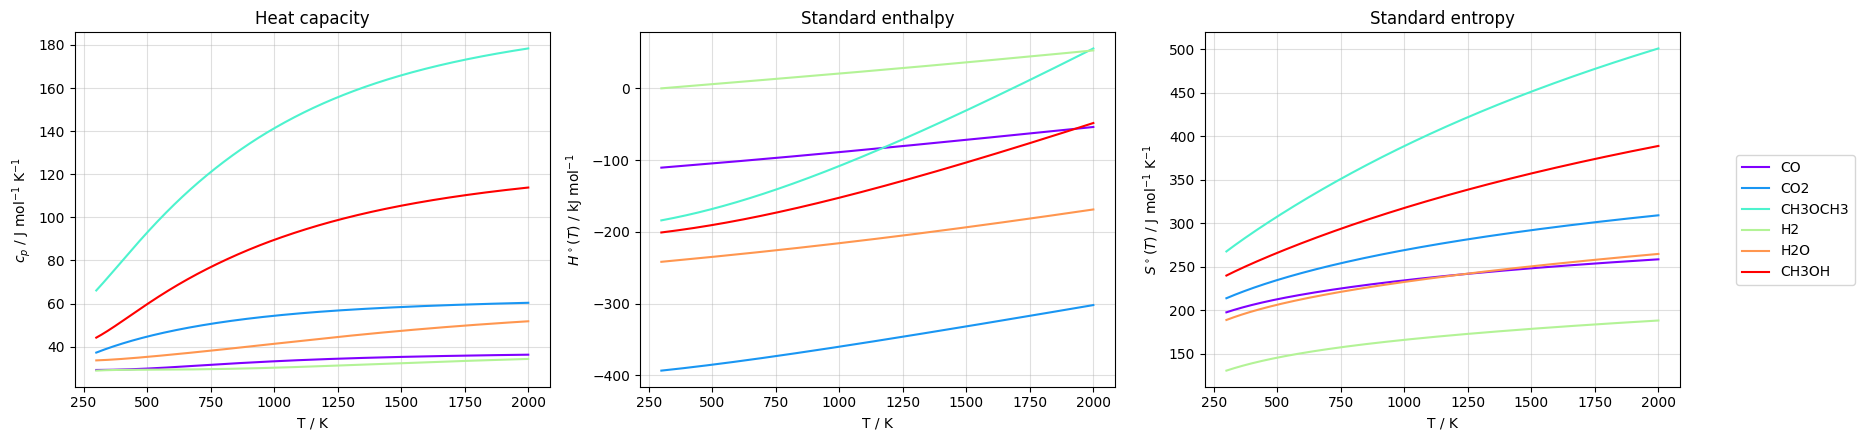

In [6]:
# Temperature range
T_range = np.linspace(300, 2000, 1000)  # # K, adjust validity range if necessary
species_list = ['CO', 'CO2', 'CH3OCH3', 'H2', 'H2O', 'CH3OH']

# # Collect data
cp_data = np.full((len(species_list), len(T_range)), np.nan)
hf_data = np.full((len(species_list), len(T_range)), np.nan)
s_data  = np.full((len(species_list), len(T_range)), np.nan)

for i, sp in enumerate(species_list):
    for j, T in enumerate(T_range):
        try:
            cp_data[i, j] = cp_T(sp, T)
            hf_data[i, j] = hf_T(sp, T)
            s_data[i, j]  = s_T(sp, T)
        except ValueError:
            pass  # T outside of NASA range → NaN remains

# Plot: 1×3 Layout
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

# # Colors from rainbow colormap
colors = plt.cm.rainbow(np.linspace(0, 1, len(species_list)))

for i, sp in enumerate(species_list):
    axes[0].plot(T_range, cp_data[i],        label=sp, color=colors[i])
    axes[1].plot(T_range, hf_data[i] / 1000, label=sp, color=colors[i])  # → kJ/mol
    axes[2].plot(T_range, s_data[i],         label=sp, color=colors[i])

axes[0].set_xlabel('T / K')
axes[0].set_ylabel(r'$c_p$ / J mol$^{-1}$ K$^{-1}$')
axes[0].set_title('Heat capacity')

axes[1].set_xlabel('T / K')
axes[1].set_ylabel(r'$H^\circ(T)$ / kJ mol$^{-1}$')
axes[1].set_title('Standard enthalpy')

axes[2].set_xlabel('T / K')
axes[2].set_ylabel(r'$S^\circ(T)$ / J mol$^{-1}$ K$^{-1}$')
axes[2].set_title('Standard entropy')

for ax in axes:
    ax.grid(True, alpha=0.4)

# Single legend to the right of the plots
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=10, frameon=True)

plt.tight_layout()
plt.show()

The plotted thermodynamic profiles reveal two critical physical insights regarding the modeled system. First, all curves exhibit smooth and continuous transitions, which confirms that the automated switching between the low-temperature and high-temperature NASA polynomial intervals is functioning correctly. No non-physical discontinuities or integration jumps are observed. Second, across the entire temperature range, dimethyl ether (DME) consistently shows the highest heat capacity and entropy values. This behavior is consistent with molecular thermodynamics. As the largest and most complex species in the system, DME possesses a greater number of internal degrees of freedom, including vibrational and rotational modes, compared to the smaller components. As a result, it can store more thermal energy and exhibits a larger number of accessible microstates.

The graphs follow the basic laws of thermodynamics, which confirms that the parameters can be used to calculate the equilibrium constants.

## 4.4. Calculating Reaction Enthalpy, Entropy, and Gibbs Free Energy
Building on the properties of individual species, the overall thermodynamic properties of the reaction network are calculated by summing the enthalpy and entropy contributions from each species based on their stoichiometric coefficients. This procedure yields the standard reaction enthalpy ($\Delta_R H^\circ$) and reaction entropy ($\Delta_R S^\circ$). From these values, the standard Gibbs free energy of reaction ($\Delta_R G^\circ$) is determined, which is then used to calculate the thermodynamic equilibrium constant ($K^°$). The model also includes pressure effects by computing the mole fraction based equilibrium constant ($K_x$), using the total change in moles ($\Delta \nu = \sum \nu_i$).

\begin{equation}
  \Delta H_R =
  \sum_i \nu_i \Delta H_{f,i}(T)
  \tag{11}
\end{equation}

\begin{equation}
  \Delta S_R =
  \sum_i \nu_i \Delta S_{f,i}(T)
  \tag{12}
\end{equation}

\begin{align}
  \Delta_RG(T) &= \Delta_RH(T)-T\,\Delta_RS(T)
  \tag{13}
\end{align}

\begin{equation}
  K^°(T) =\exp\left(-\frac{\Delta_RG(T)}{R\,T}\right)
  \tag{14}
\end{equation}

\begin{equation}
K_x(T,p) = K^\circ(T) \left(\frac{p^\circ}{p}\right)^{\sum \nu_i}
\tag{15}
\end{equation}

* **$T$**: Absolute operating temperature, measured in Kelvin (K).
* **$\Delta H$**: Standard reaction enthalpy, measured in kilojoules per mole (kJ/mol).
* **$\Delta S$**: Standard reaction entropy, measured in joules per mole-kelvin (J/mol·K).
* **$\Delta G$**: Standard Gibbs free energy of reaction, measured in kilojoules per mole (kJ/mol).
* **$K_p$**: Thermodynamic equilibrium constant.
* **$K_x$**: Mole fraction-based equilibrium constant, evaluated at a specific system pressure (e.g., $p = 1 \text{ bar}$).


In [7]:
def reaction_enthalpy(reaction, T):
    """
    Calculate the reaction enthalpy (ΔH) at a given temperature T for a specified reaction.
    
    Parameters:
    - reaction: A list of tuples representing the reaction. Each tuple contains (species, coefficient).
                Coefficients should be negative for reactants and positive for products.
    - T: Temperature in Kelvin (float).
    
    Returns:
    - ΔH: Reaction enthalpy in J/mol (float).
    """
    delta_H = 0.0
    for species, coeff in reaction:
        hf = hf_T(species, T)
        delta_H += coeff * hf
    return delta_H

def reaction_entropy(reaction, T):
    """
    Calculate the reaction entropy (ΔS) at a given temperature T for a specified reaction.
    
    Parameters:
    - reaction: A list of tuples representing the reaction. Each tuple contains (species, coefficient).
                Coefficients should be negative for reactants and positive for products.
    - T: Temperature in Kelvin (float).
    
    Returns:
    - ΔS: Reaction entropy in J/(mol*K) (float).
    """
    delta_S = 0.0
    for species, coeff in reaction:
        S = s_T(species, T)
        delta_S += coeff * S
    return delta_S

def reaction_gibbs_free_energy(reaction, T):
    """
    Calculate the reaction Gibbs free energy (ΔG) at a given temperature T for a specified reaction.
    
    Parameters:
    - reaction: A list of tuples representing the reaction. Each tuple contains (species, coefficient).
                Coefficients should be negative for reactants and positive for products.
    - T: Temperature in Kelvin (float).
    
    Returns:
    - ΔG: Reaction Gibbs free energy in J/mol (float).
    """
    delta_H = reaction_enthalpy(reaction, T)
    delta_S = reaction_entropy(reaction, T)
    delta_G = delta_H - T * delta_S
    return delta_G

def eq_const_p(reaction, T):
    """
    Calculate the equilibrium constant (K) at a given temperature T for a specified reaction.
    
    Parameters:
    - reaction: A list of tuples representing the reaction. Each tuple contains (species, coefficient).
                Coefficients should be negative for reactants and positive for products.
    - T: Temperature in Kelvin (float).
    
    Returns:
    - K: Equilibrium constant (dimensionless).
    """
    delta_G = reaction_gibbs_free_energy(reaction, T)
    K = np.exp((-delta_G )/ (R * T))
    return K

# k_x = K_p * p^Δν

def stoich_coeff_change(reaction):
    """Change in molar stoichiometric coefficient Δν = Σ vi."""
    dnu = 0
    for species, coeff in reaction:
        dnu += coeff
    return dnu

def eq_const_x(reaction, T, p):
    """
    Calculate the equilibrium constant (K_x) at a given temperature T and pressure p for a specified reaction.
    
    Parameters:
    - reaction: A list of tuples representing the reaction. Each tuple contains (species, coefficient).
                Coefficients should be negative for reactants and positive for products.
    - T: Temperature in Kelvin (float).
    - p: Pressure in bar (float).
    
    Returns:
    - K_x: Equilibrium constant (dimensionless).
    """
    K_p = eq_const_p(reaction, T)
    dnu = stoich_coeff_change(reaction)
    K_x = K_p * (p ** (-dnu))
    return K_x


print("\n--- Thermodynamic Properties Calculation ---")
# Validation values for Temperatures 298,15 K, 500 K, 1000 K, printed as a table for readability

print(f"{'Reaction':<10} {'T (K)':<10} {'ΔH (kJ/mol)':<20} {'ΔS (J/mol*K)':<20} {'ΔG (kJ/mol)':<20} {'K_p':<15} {'K_x (p=1 bar)':<20}")
reaction_names = ['R1', 'R2', 'R4', 'R3']  # Adjusted order for independence
for T in validation_temperatures:
    print("-" * 120)
    for i in range(4):
        r_reaction = reaction_tuples[i]
        r_name = reaction_names[i]
        delta_H = reaction_enthalpy(r_reaction, T) / 1000  # Convert to kJ/mol
        delta_S = reaction_entropy(r_reaction, T)
        delta_G = reaction_gibbs_free_energy(r_reaction, T) / 1000  # Convert to kJ/mol
        K_p = eq_const_p(r_reaction, T)
        K_x = eq_const_x(r_reaction, T, p=1)  # Assuming p=1 bar for K_x
        print(f"{r_name:<10} {T:<10.2f} {delta_H:<20.2f} {delta_S:<20.2f} {delta_G:<20.2f} {K_p:<15.2e} {K_x:<20.2e}")


--- Thermodynamic Properties Calculation ---
Reaction   T (K)      ΔH (kJ/mol)          ΔS (J/mol*K)         ΔG (kJ/mol)          K_p             K_x (p=1 bar)       
------------------------------------------------------------------------------------------------------------------------
R1         298.15     -49.25               -177.18              3.57                 2.37e-01        2.37e-01            
R2         298.15     -90.40               -219.20              -25.05               2.44e+04        2.44e+04            
R4         298.15     -24.05               -23.41               -17.08               9.81e+02        9.81e+02            
R3         298.15     41.15                42.02                28.62                9.68e-06        9.68e-06            
------------------------------------------------------------------------------------------------------------------------
R1         500.00     -57.86               -199.42              41.85                4.24e-05        4

The results are consistent with basic thermodynamic principles. Strongly exothermic and mole reducing reactions $R_1$ and $R_2$ show a clear decrease in equilibrium constant at higher temperatures because the entropic term becomes more dominant in the Gibbs free energy. In contrast, the reverse water-gas shift reaction ($R_3$) becomes more favorable as temperature increases, while the methanol dehydration to DME ($R_4$) shows only small changes in equilibrium behavior due to its relatively small entropy change.

The calculated reaction heats are in agrement with literature sources. Lawes et. al. [8] give $\Delta_\mathrm{R}\mathrm{H}°$ for reactions 1 to 3, Kansha et. al. [9] gives the standart reaction heat for the methanol dehydration ($\mathrm{R}_4$):

| Reaction | R1 | R2 | R3 | R4 |
|----------|--------|-------|------|------|
| $\Delta_\mathrm{R}\mathrm{H}$ / kJ $\mathrm{mol}^{-1}$ | -49,5 | -90,6 | 41,2 | -23,4 |

These values are reported for standart condistions. If we compare them with the values obtained from our calculations (for 1 bar and 298.15 K), they show high accordance. The slight deviations obtained from our calculated results could be explained by rounding errors during the calculation, or the fact that our values are obtained from mathemtical expressions and fitted data from the NASA database. Either way, the accordance of our data with literature values is high enough, for us to be confident in using the values in the calculation of the reaction extend and in extension the equillibrium yield.

### 4.5. Literature Reference Values for Equilibrium Constants

**For R1, R2, R3** 

The equilibrium constants presented are derived from the empirically fitted correlations provided in the referenced literature. Specifically, the constants for reactions $R_2$ and $R_3$ are obtained directly from the source’s analytical expressions, while the equilibrium constant for reaction $R_1$ is determined via the stoichiometric consistency relation $K_p^\circ(R_1) = K_p^\circ(R_2) \cdot K_p^\circ(R_3)$. It should be noted that the source material exclusively reports the thermodynamic equilibrium constants ($K_p^\circ$). Consequently, enthalpy ($\Delta_R H^\circ$), entropy ($\Delta_R S^\circ$), and Gibbs free energy ($\Delta_R G^\circ$) of reaction must be derived analytically [4].


| Reaction | T (°C) | T (K) | K_p° | Unit |
|----------|--------|-------|------|------|
| R1: CO₂ + 3H₂ ⇌ CH₃OH + H₂O | 200 | 473.15 | 7.66 × 10⁻⁵ | bar⁻² |
| R2: CO + 2H₂ ⇌ CH₃OH          | 200 | 473.15 | 1.77 × 10⁻²  | bar⁻² |
| R3: CO₂ + H₂ ⇌ CO + H₂O       | 200 | 473.15 | 4.33 × 10⁻³  | —     |
| R1: CO₂ + 3H₂ ⇌ CH₃OH + H₂O | 250 | 523.15 | 1.89 × 10⁻⁵ | bar⁻² |
| R2: CO + 2H₂ ⇌ CH₃OH          | 250 | 523.15 | 1.66 × 10⁻³  | bar⁻² |
| R3: CO₂ + H₂ ⇌ CO + H₂O       | 250 | 523.15 | 1.14 × 10⁻²  | —     |
| R2: CO + 2H₂ ⇌ CH₃OH          | 300 | 573.15 | 2.28 × 10⁻⁴  | bar⁻² |
| R1: CO₂ + 3H₂ ⇌ CH₃OH + H₂O | 300 | 573.15 | 5.72 × 10⁻⁶ | bar⁻² |
| R3: CO₂ + H₂ ⇌ CO + H₂O       | 300 | 573.15 | 2.51 × 10⁻²  | —     |

**For R4** 

> > **Note:** Temperature data points evaluated for reaction $R_4$ (498 K, 523 K, and 573 K) exhibit a slight deviation from the intervals applied to reactions $R_1$ through $R_3$ (473 K, 523 K, and 573 K). While the higher temperature conditions representing 250°C and 300°C are practically identical across both datasets with a negligible margin (Δ = 0.15 K), a distinct variance exists at the lowest temperature bound, which is evaluated here at 225°C compared to the 200°C baseline used previously [5].

| Reaction | T (°C) | T (K) | K_p° | ΔG°r (kJ mol⁻¹) | Unit |
|----------|--------|-------|------|-----------------|------|
| R4: 2 CH₃OH ⇌ DME + H₂O | 225 | 498 | 12.948 | −10.604 | — |
| R4: 2 CH₃OH ⇌ DME + H₂O | 250 | 523 | 10.810 | −10.351 | — |
| R4: 2 CH₃OH ⇌ DME + H₂O | 300 | 573 |  7.318 |  −9.482 | — |




An apparent numerical deviation can be observed when comparing our explicitly calculated equilibrium constants ($K_p$) with the literature values provided by Graaf & Winkelman (2016). This discrepancy does not originate from our mathematical implementation or the ideal gas assumption used in our exponential relation $K^\circ(T) = \exp(-\Delta_R G(T) / RT)$. By definition, the thermodynamic standard equilibrium constant $K^\circ$ is always referenced to the ideal gas state at 1 bar, regardless of the actual reactor pressure. Graaf’s use of the SRK (Soave-Redlich-Kwong) equation of state was exclusively applied to correct experimental high-pressure measurements (via fugacity coefficients) back to this ideal standard state, not to alter the fundamental definition of $K^\circ$.

The root cause of the deviation lies entirely in the extreme sensitivity of the exponential function to minor variations in the standard thermodynamic baseline data. As explicitly stated in the referenced paper, shifting the standard Gibbs free energy of formation ($\Delta_f G^\circ$) for methanol by a mere 0.5% alters the resulting equilibrium constant by approximately 33%. While our computational model strictly relies on the unmodified NIST-JANAF thermochemical tables, Graaf & Winkelman deliberately refitted the standard formation energies of methanol and carbon monoxide to match their specific experimental high-pressure reactor data. Consequently, the observed variance is not a computational error, but rather an expected statistical offset arising from the utilization of different foundational thermodynamic databases.

**Claude explanation**

https://claude.ai/share/51f3a95c-b91f-4825-b6d8-cbcd173ce7e9

### 4.6. Visualizing the Values for $\Delta_{R}H(T)$, $\Delta_{R}S(T)$ and $\Delta_{R}G(T)$

To comprehensively evaluate the thermodynamic behavior of the synthesis network over a wide operational spectrum, properties were evaluated continuously from 250 K to 2000 K. The resulting visualizations reflect the temperature dependence described by the Gibbs–Helmholtz relationship.


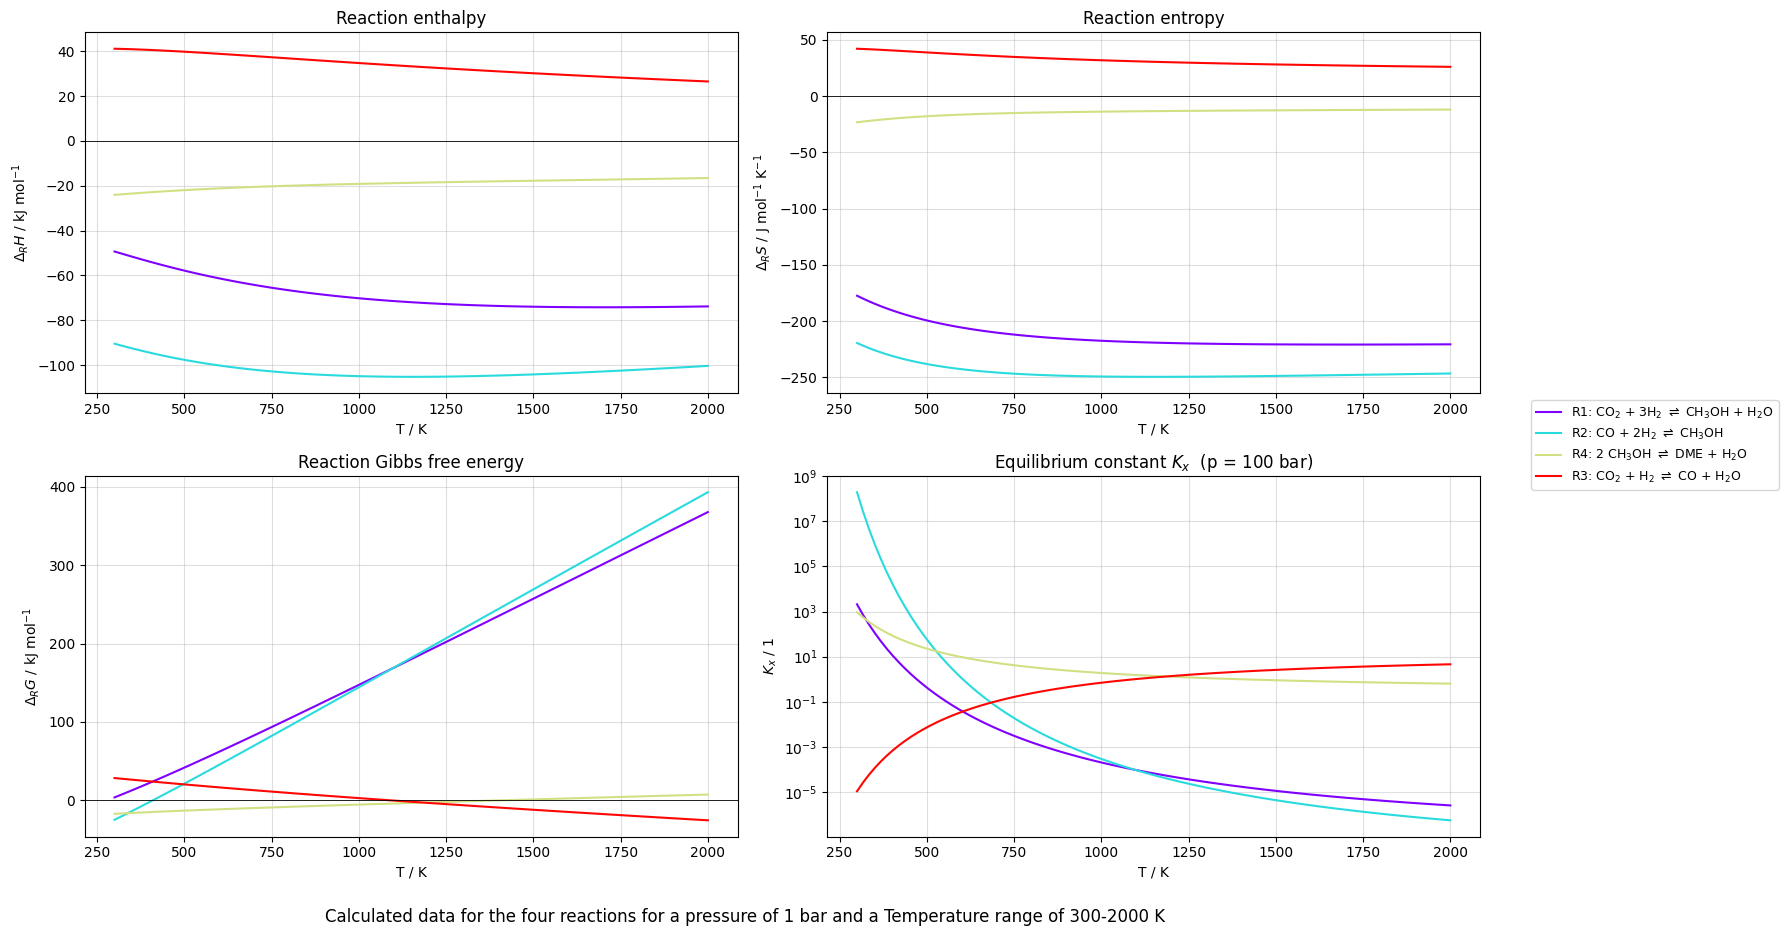

In [8]:
T_range = np.linspace(300, 2000, 100)

reaction_labels = [
    r'R1: CO$_2$ + 3H$_2$ $\rightleftharpoons$ CH$_3$OH + H$_2$O',
    r'R2: CO + 2H$_2$ $\rightleftharpoons$ CH$_3$OH',
    r'R4: 2 CH$_3$OH $\rightleftharpoons$ DME + H$_2$O',
    r'R3: CO$_2$ + H$_2$ $\rightleftharpoons$ CO + H$_2$O',
]

p_ref = 100  # bar — reference pressure for K_x calculation, can be adjusted as needed

# --- calculating data ---
dH_data = np.full((4, len(T_range)), np.nan)
dS_data = np.full((4, len(T_range)), np.nan)
dG_data = np.full((4, len(T_range)), np.nan)
Kx_data = np.full((4, len(T_range)), np.nan)

for r_idx in range(4):
    for j, T in enumerate(T_range):
        try:
            dH_data[r_idx, j] = reaction_enthalpy(reaction_tuples[r_idx], T)
            dS_data[r_idx, j] = reaction_entropy(reaction_tuples[r_idx], T)
            dG_data[r_idx, j] = reaction_gibbs_free_energy(reaction_tuples[r_idx], T)
            Kx_data[r_idx, j] = eq_const_x(reaction_tuples[r_idx], T, p_ref)
        except ValueError:
            pass

# --- 2×2 Plot with shared legend ---
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
axes = axes.flatten()  # [ΔH, ΔS, ΔG, K_x]

# defining colors for consistent legend, using rainbow colormap with 4 distinct colors for the 4 reactions
colors = plt.cm.rainbow(np.linspace(0, 0.99, 4))

for r_idx in range(4):
    axes[0].plot(T_range, dH_data[r_idx] / 1000, label=reaction_labels[r_idx], color=colors[r_idx])
    axes[1].plot(T_range, dS_data[r_idx],         label=reaction_labels[r_idx], color=colors[r_idx])
    axes[2].plot(T_range, dG_data[r_idx] / 1000,  label=reaction_labels[r_idx], color=colors[r_idx])
    axes[3].plot(T_range, Kx_data[r_idx],          label=reaction_labels[r_idx], color=colors[r_idx])

axes[0].set_ylabel(r'$\Delta_R H$ / kJ mol$^{-1}$')
axes[0].set_title('Reaction enthalpy')

axes[1].set_ylabel(r'$\Delta_R S$ / J mol$^{-1}$ K$^{-1}$')
axes[1].set_title('Reaction entropy')

axes[2].set_ylabel(r'$\Delta_R G$ / kJ mol$^{-1}$')
axes[2].set_title('Reaction Gibbs free energy')

axes[3].set_ylabel(r'$K_x$ / 1')
axes[3].set_title(f'Equilibrium constant $K_x$  (p = {p_ref} bar)')
axes[3].set_yscale('log')  # log-scale because of order of magnitude (R2 >> R3)

for ax in axes:
    ax.set_xlabel('T / K')
    ax.grid(True, alpha=0.4, which='both')
    ax.axhline(0, color='k', lw=0.6)

# single legend to the right of the plots
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=9, frameon=True)
fig.text(0.5, -0.03, 'Calculated data for the four reactions for a pressure of 1 bar and a Temperature range of 300-2000 K', ha='center', fontsize=12)

plt.tight_layout()
plt.show()

The graphs show that the reaction enthalpies ($\Delta_R H$) and entropies ($\Delta_R S$) exhibit only mild temperature dependencies, aligning closely with standard specific heat capacity limits. However, the standard Gibbs free energy ($\Delta_R G$) demonstrates a strong linear divergence due to the increasingly dominant $-T\Delta_R S$ term. The zero-crossing points in the $\Delta_R G$ profile explicitly identify the thermodynamic reversal temperatures, illustrating where the entropically unfavorable methanol synthesis reactions ($R_1$ and $R_2$) transition from spontaneous to non-spontaneous. 

It is important to note, that the above plottet values are calculated for the standart pressure of 1 bar. For higher pressures, the calculation of the gibbs free Energy needs to be furthered. Assuming ideal gas conditions, we can write the equilibrium constant like in equation XXXXXXX. From this, pressure corrected, equillibrium constant, we can calculate a new, pressure corrected gibbs-free-energy for the reactions.

\begin{equation}
K_x(T,p) = K^\circ(T) \left( \frac{p^\circ}{p} \right)^{\Sigma \nu}
\tag{16}
\end{equation}

\begin{equation}
\Delta_R G(T,p) = -RT \ln\left(K_x(T,p)\right)
\tag{17}
\end{equation}

These, pressure corrected, values are visualized below.

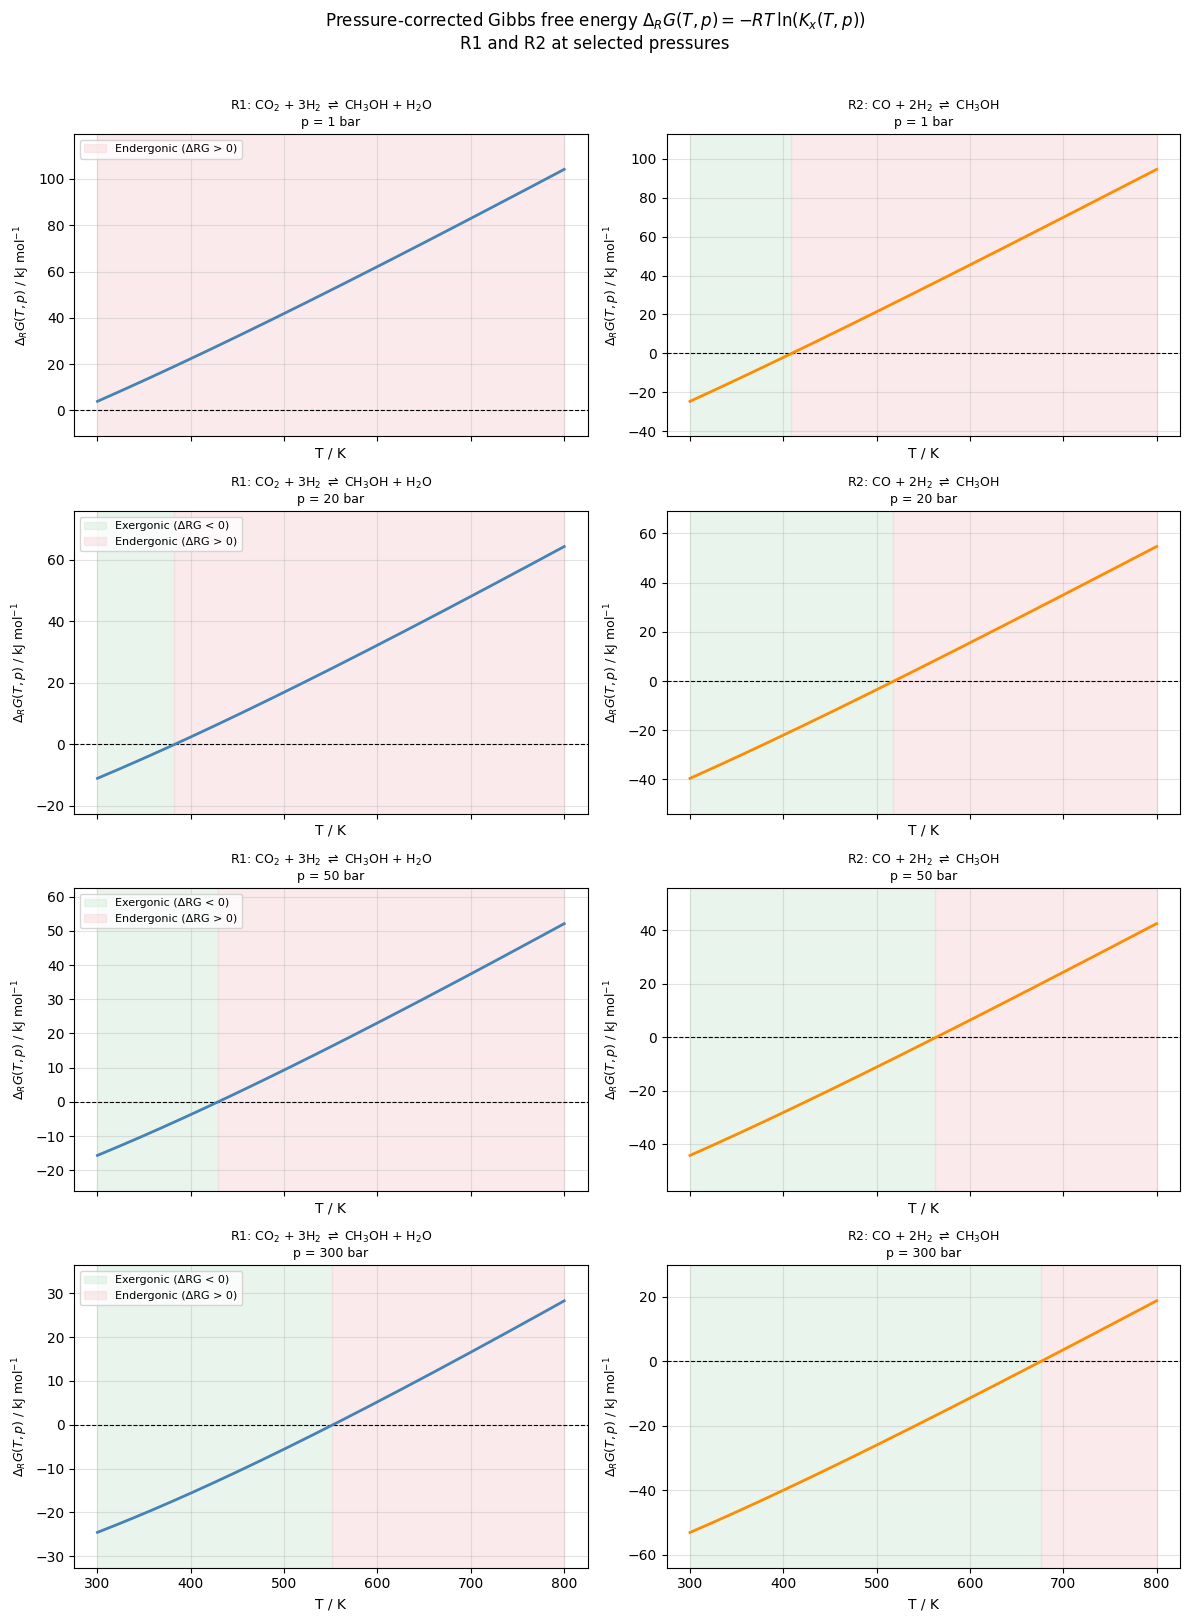

In [9]:
# =============================================================================
# Pressure-corrected Gibbs Free Energy: ΔRG(T, p) = -RT * ln(K_x(T, p))
# 
# Background:
#   The standard Gibbs free energy ΔRG°(T) is calculated at p° = 1 bar.
#   For real operating pressures, K_x(T, p) already incorporates the pressure
#   correction via:  K_x = K_p * (p°/p)^Δν
#   Inverting this relation gives the pressure-corrected Gibbs free energy:
#       ΔRG(T, p) = -RT * ln(K_x(T, p))
#   This equals ΔRG°(T) only at p = 1 bar; at other pressures it reflects
#   the true thermodynamic driving force under process conditions.
#
# Reaction index convention in reaction_tuples:
#   Index 0 → R1: CO2 + 3H2  ⇌ CH3OH + H2O
#   Index 1 → R2: CO  + 2H2  ⇌ CH3OH
#   Index 2 → R4: 2 CH3OH    ⇌ DME + H2O   (not shown here)
#   Index 3 → R3: CO2 + H2   ⇌ CO + H2O    (not shown here)
# =============================================================================

# --- Parameters ---
T_range_vis  = np.linspace(300, 800, 300)      # Temperature range of interest [K]
pressures    = [1, 20, 50, 300]                # Pressures to evaluate [bar]
rxn_indices  = [0, 1]                          # R1 (index 0) and R2 (index 1)
rxn_labels   = [
    r'R1: CO$_2$ + 3H$_2$ $\rightleftharpoons$ CH$_3$OH + H$_2$O',
    r'R2: CO + 2H$_2$ $\rightleftharpoons$ CH$_3$OH',
]

# --- Pre-compute ΔRG(T, p) for each reaction and each pressure ---
# Shape of dRG_data: (n_reactions, n_pressures, n_temperatures)
dRG_data = np.full((len(rxn_indices), len(pressures), len(T_range_vis)), np.nan)

for ri, r_idx in enumerate(rxn_indices):
    for pi, p in enumerate(pressures):
        for ti, T in enumerate(T_range_vis):
            try:
                # Retrieve the pressure-corrected mole-fraction equilibrium constant.
                # K_x = K_p * (p° / p)^Δν, where p° = 1 bar is implicit in eq_const_x().
                K_x = eq_const_x(reaction_tuples[r_idx], T, p)

                # Guard against non-positive K_x values (unphysical; would cause log errors).
                if K_x > 0:
                    # Invert the equilibrium constant definition to obtain ΔRG(T, p).
                    # Units: J/mol → convert to kJ/mol for readability.
                    dRG_data[ri, pi, ti] = -R * T * np.log(K_x) / 1000
            except ValueError:
                # Temperature outside valid NASA-Glenn range for this species → leave as NaN.
                pass

# --- Plotting ---
# Layout: one figure per pressure (4 total), each with 2 subplots side by side (R1 | R2).
# The exergonic region (ΔRG < 0, reaction thermodynamically favored) is shaded green.
# The endergonic region (ΔRG > 0, reaction not favored)               is shaded red.

fig, axes = plt.subplots(
    nrows=len(pressures), ncols=len(rxn_indices),
    figsize=(12, 4 * len(pressures)),
    sharex=True
)

# Fixed colors per reaction, consistent across all pressure subplots
rxn_colors = ['steelblue', 'darkorange']

for pi, p in enumerate(pressures):
    for ri, r_idx in enumerate(rxn_indices):
        ax = axes[pi, ri]
        dRG = dRG_data[ri, pi, :]

        # Find the zero-crossing temperature (transition point exergonic ↔ endergonic)
        # np.interp requires a monotonic x-axis, so we search for sign changes manually.
        sign_changes = np.where(np.diff(np.sign(dRG)))[0]

        if len(sign_changes) > 0:
            # Take the first zero crossing as the transition temperature
            T_cross = T_range_vis[sign_changes[0]]
            # Exergonic region: T < T_cross → shade the full vertical extent
            ax.axvspan(T_range_vis[0], T_cross, color='#d4edda', alpha=0.5, zorder=0, label='Exergonic (ΔRG < 0)')
            # Endergonic region: T > T_cross → shade the full vertical extent
            ax.axvspan(T_cross, T_range_vis[-1], color='#f8d7da', alpha=0.5, zorder=0, label='Endergonic (ΔRG > 0)')
        else:
            # No crossing found: shade the entire plot in whichever region applies
            color = '#d4edda' if np.nanmean(dRG) < 0 else '#f8d7da'
            label = 'Exergonic (ΔRG < 0)' if np.nanmean(dRG) < 0 else 'Endergonic (ΔRG > 0)'
            ax.axvspan(T_range_vis[0], T_range_vis[-1], color=color, alpha=0.5, zorder=0, label=label)

        # --- Zero line for visual reference ---
        ax.axhline(0, color='black', linewidth=0.8, linestyle='--', zorder=2)

        # --- Main curve ---
        ax.plot(T_range_vis, dRG, color=rxn_colors[ri], linewidth=2.0, zorder=3)

        # --- Axis limits: clip y to a physically meaningful window ---
        # (avoids extreme values at low T distorting the view)
        finite_vals = dRG[np.isfinite(dRG)]
        if len(finite_vals) > 0:
            y_margin = 0.15 * (np.nanmax(finite_vals) - np.nanmin(finite_vals) + 1)
            ax.set_ylim(np.nanmin(finite_vals) - y_margin, np.nanmax(finite_vals) + y_margin)

        # --- Labels ---
        ax.set_xlabel('T / K', fontsize=10)
        ax.set_ylabel(r'$\Delta_R G(T,p)$ / kJ mol$^{-1}$', fontsize=9)
        ax.set_title(f'{rxn_labels[ri]}\np = {p} bar', fontsize=9)
        ax.grid(True, alpha=0.35)

        # --- Legend only in the first subplot of each row ---
        if ri == 0:
            ax.legend(fontsize=8, loc='upper left')

fig.suptitle(
    r'Pressure-corrected Gibbs free energy $\Delta_R G(T,p) = -RT\,\ln(K_x(T,p))$'
    '\nR1 and R2 at selected pressures',
    fontsize=12, y=1.01
)
plt.tight_layout()
plt.show()

The plots above show that the pressure-corrected Gibbs free energy of reactions 1 and 2 becomes more favorable at increased pressures. At high pressures, the reactions become more exergonic at low temperatures, enabling them to proceed spontaneously. This pressure dependence is a direct consequence of Le Chatelier's principle: both R1 ($\Delta\nu = -2$) and R2 ($\Delta\nu = -2$) proceed with a significant reduction in the total number of moles. An increase in pressure therefore shifts the equilibrium strongly towards the products, which is reflected in the increasingly negative $\Delta_R G(T,p)$ at elevated pressures.

For the yield of DME to be calculated later, this should result in a higher yield at high pressures and low temperatures. This is because for the formation of DME through methanol dehydration, methanol must be present in the reactor. When using a feed of purely $\mathrm{CO}$, $\mathrm{CO}_2$ and $\mathrm{H}_2$, reactions R1 or R2 need to take place for any DME to be formed. At temperatures above the respective zero-crossing, both reactions become endergonic, meaning the equilibrium lies strongly on the reactant side. As visible in the plots, increasing the pressure from 1 bar to 300 bar shifts this transition temperature by approximately 250 K for R1 and approximately 267,6 K for R2, significantly expanding the operable temperature window for spontaneous methanol synthesis. Since no significant amount of methanol is formed above these transition temperatures, the DME yield is expected to approach zero, even though the dehydration reaction R4 itself remains thermodynamically favorable throughout.

To calculate the reaction extend, we later use the equillibrum constant $K_x$. The pressure dependency of that constant i shown with the plot below:

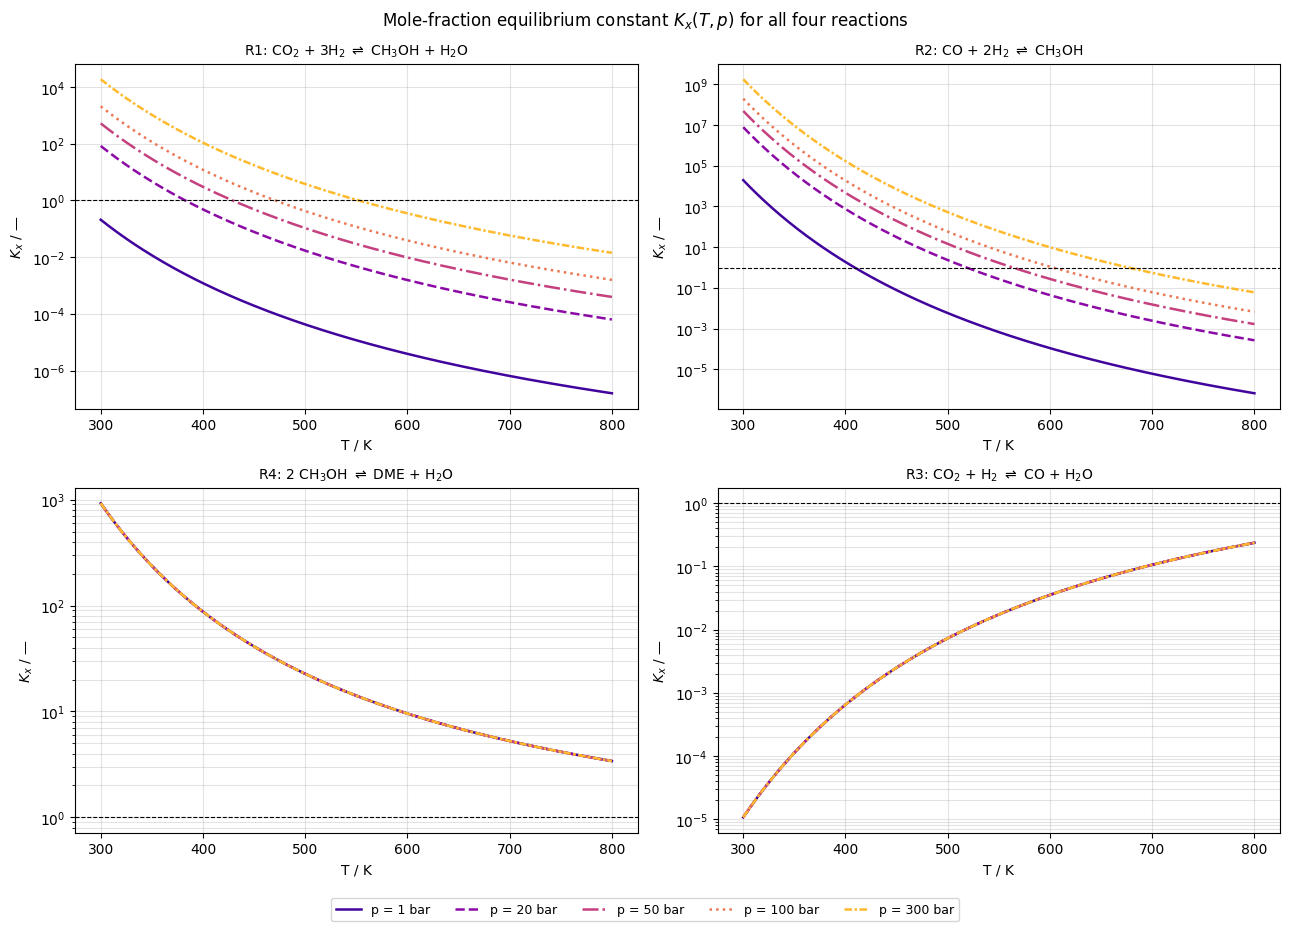

In [10]:
# =============================================================================
# K_x(T, p) for all four reactions at selected pressures
#
# K_x is the mole-fraction based equilibrium constant, which incorporates the
# pressure correction via: K_x = K_p * (p° / p)^Δν  (p° = 1 bar implicit)
# A higher K_x indicates a stronger thermodynamic driving force toward products.
# Plotted on a logarithmic y-axis due to the large range of magnitudes.
#
# Reaction index convention in reaction_tuples:
#   Index 0 → R1: CO2 + 3H2  ⇌ CH3OH + H2O   (Δν = -3)
#   Index 1 → R2: CO  + 2H2  ⇌ CH3OH          (Δν = -2)
#   Index 2 → R4: 2 CH3OH    ⇌ DME + H2O      (Δν =  0)
#   Index 3 → R3: CO2 + H2   ⇌ CO + H2O       (Δν =  0)
# =============================================================================

# --- Parameters ---
T_range_kx   = np.linspace(300, 800, 300)       # Temperature range [K]
pressures_kx = [1, 20, 50, 100, 300]            # Pressures to evaluate [bar]
all_rxn_indices = [0, 1, 2, 3]                  # All four reactions
all_rxn_labels  = [
    r'R1: CO$_2$ + 3H$_2$ $\rightleftharpoons$ CH$_3$OH + H$_2$O',
    r'R2: CO + 2H$_2$ $\rightleftharpoons$ CH$_3$OH',
    r'R4: 2 CH$_3$OH $\rightleftharpoons$ DME + H$_2$O',
    r'R3: CO$_2$ + H$_2$ $\rightleftharpoons$ CO + H$_2$O',
]

# Use a perceptually uniform colormap to distinguish pressure levels
pressure_colors = plt.cm.plasma(np.linspace(0.1, 0.85, len(pressures_kx)))
pressure_linestyles = ['-', '--', '-.', ':', (0, (3, 1, 1, 1))]  # solid, dashed, dashdot, dotted, densely dashdotted

# --- Pre-compute K_x(T, p) for all reactions and pressures ---
# Shape: (n_reactions, n_pressures, n_temperatures)
Kx_all = np.full((len(all_rxn_indices), len(pressures_kx), len(T_range_kx)), np.nan)

for ri, r_idx in enumerate(all_rxn_indices):
    for pi, p in enumerate(pressures_kx):
        for ti, T in enumerate(T_range_kx):
            try:
                Kx_all[ri, pi, ti] = eq_const_x(reaction_tuples[r_idx], T, p)
            except ValueError:
                # Temperature outside valid NASA-Glenn range → leave as NaN
                pass

# --- Plotting: 2x2 grid, one subplot per reaction ---
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()  # Index order: R1, R2, R4, R3

for ri, r_idx in enumerate(all_rxn_indices):
    ax = axes[ri]

    for pi, p in enumerate(pressures_kx):
        ax.plot(
            T_range_kx,
            Kx_all[ri, pi, :],
            color=pressure_colors[pi],
            linestyle=pressure_linestyles[pi],
            linewidth=1.8,
            label=f'p = {p} bar'
        )

    # Reference line at K_x = 1: equilibrium point where products = reactants
    ax.axhline(1, color='black', linewidth=0.8, linestyle='--', zorder=2)

    ax.set_yscale('log')
    ax.set_xlabel('T / K', fontsize=10)
    ax.set_ylabel(r'$K_x$ / —', fontsize=10)
    ax.set_title(all_rxn_labels[ri], fontsize=10)
    ax.grid(True, alpha=0.35, which='both')

# --- Shared legend below the plots ---
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc='lower center',
    ncol=len(pressures_kx),
    fontsize=9,
    frameon=True,
    bbox_to_anchor=(0.5, -0.04)
)

fig.suptitle(
    r'Mole-fraction equilibrium constant $K_x(T,p)$ for all four reactions',
    fontsize=12
)
plt.tight_layout()
plt.show()

We can observe that the equilibrium constant $K_x$ shows a pressure dependency for reactions R1 and R2, while remaining unchanged for reactions R3 and R4. This is because R1 and R2 have a non-zero total stoichiometric change ($\Delta\nu = -2$ for both), while R3 and R4 do not change the total number of moles ($\Delta\nu = 0$). Using the definition of $K_x$ given in equation XXXXXXX, $K_x$ reduces to $K^\circ$ for $\Delta\nu = 0$, making these two reactions pressure-independent.

## 5. Determination of the Reaction Extents ($\xi$) from Equilibrium Constants ($K_x$)

In the preceding sections, the mole fraction-based equilibrium constant, $K_x$, was calculated. For a single independent reaction, this constant is fundamentally defined as:

\begin{align}
    K_x &= \prod_i x_i^{\nu_i}
    \tag{18}
\end{align}

The primary objective is to compute the extent of reaction, $\xi_j$, for all targeted reactions $j \in \{1,2,3,4\}$. To achieve this, the molar balance for each component must be established. The steady-state molar flow rate of component $i$ exiting a multiple-reaction network is formulated as:


\begin{align}
    \dot{n_{i,out}} &= \dot{n_{i,in}} + \sum_{j=1}^N \nu_{i,j} \cdot \xi_{j}
    \tag{19}
\end{align}

Consequently, the total effluent molar flow rate of the mixture is the sum of all individual component flows:

\begin{align}
    \dot{n_{out}} &= \dot{n_{in}} + \sum_{j=1}^N \xi_{j} \cdot (\sum_i^M \nu_{j, i})
    \tag{20}
\end{align}

Utilizing these mass balance formulations, the molar fraction of any species $i$ at the outlet ($x_{i,out}$) can be expressed explicitly as a function of the reaction extents:

\begin{align}
  x_{i,out} &= \frac{\dot n_{i,out}}{\dot n_{out}}=\frac{\dot{n_{i,in}} + \sum_{j=1}^N \nu_{i,j} \cdot \xi_{j}}{\dot{n_{in}} + \sum_{j=1}^N \xi_{j} \cdot (\sum_i^M \nu_{j, i})}
  \tag{21}
\end{align}

By substituting this mole fraction definition into the equilibrium constant expression, a system of nonlinear equations is constructed. Providing an initial guess for the reaction extents ($\xi$), the numerical solution is obtained by iteratively finding the roots of the following objective function for the designated key reactions:

\begin{align}
    K_{j,i} - \prod_i x_{j,i}^{\nu_i} = 0
    \tag{22}
\end{align}

Successfully minimizing this residual function yields a numerical solution for the reaction extents ($\xi$).

* **$K_{x,j}$**: Mole fraction-based equilibrium constant for reaction $j$.
* **$x_{i}$ / $x_{i,out}$**: Mole fraction of species $i$.
* **$\nu_{i,j}$**: Stoichiometric coefficient of species $i$ in reaction $j$ (assigned negative values for reactants and positive values for products).
* **$\xi_j$**: Extent of reaction for reaction $j$ (indicates the progression of the reaction).
* **$\dot{n}_{i,in}$ / $\dot{n}_{i,out}$**: Inlet and outlet molar flow rates of component $i$.
* **$\dot{n}_{in}$ / $\dot{n}_{out}$**: Total inlet and outlet molar flow rates of the entire mixture.
* **$N$**: Total number of independent reactions in the network.
* **$M$**: Total number of chemical species involved in the system.


In [57]:
from scipy.optimize import root

def material_balance(reaction, xi, n_in, rc_ind):
    """
    Calculate the material balance for a given reaction, extent of reaction (xi), and initial moles (n_in).
    
    Parameters:
    - reaction: A list of tuples representing the reaction. Each tuple contains (species, coefficient).
                Coefficients should be negative for reactants and positive for products.
    - xi: Extent of reactions (array of floats).
    - n_in: Initial moles of each species as an array [mol/h].
    - rc_ind: Indexes of the reactions for which to solve. (array of ints)
    
    Returns:
    - n_out: Final moles of each species after the reaction as an array [mol/h].
    """
    n_out = n_in.copy()                                     # Start with initial moles
    for i in range(min(len(rc_ind), len(reaction))):        # Loop through the reactions up to the specified index
        for j in range(len(n_in)):                          # Calculate the change in moles for each species based on the reaction coefficients and extent of reaction
            species, coeff = reaction[rc_ind[i]][j]
            n_out[j] = n_out[j] + (coeff * xi[i])           # Update the moles based on the extent of reaction and the stoichiometric coefficients
    return n_out                                            # Return the final moles after the reaction for the solver to compare and refine the guess of xi

def mole_fraction(n_out):
    """
    Calculate the mole fraction of each species given the final moles.
    
    Parameters:
    - n_out: Final moles of each species as an array [mol/h].
    
    Returns:
    - x: Mole fraction of each species as an array.
    """
    total_moles = np.sum(n_out)
    if total_moles == 0:
        return np.zeros_like(n_out)  # Avoid division by zero
    x = n_out / total_moles
    return x

def equilibrium_residuals(xi, reaction_list, n_in, T, p, reac_index):
    """
    Residuals of the equilibrium conditions in direct (non-log) form:
    res_k = K_x * prod(x_educt^|nu|) - prod(x_prod^nu) = 0
    
    Parameters
    ----------
    xi           : array, shape (n_reactions,)
    reaction_list: list of reactions in tuple form
    n_in         : array, shape (n_species,)
    T            : float - temperature [K]
    p            : float - pressure [bar]
    reac_index   : list of int
    
    Returns
    -------
    res : array, shape (n_reactions,)
    """
    n_out = material_balance(reaction_list, xi, n_in, reac_index)
    total = np.sum(n_out)
    x = np.clip(n_out / total, 1e-12, 1.0)

    res = np.zeros(len(reac_index))
    for k, j in enumerate(reac_index):
        K_x = eq_const_x(reaction_list[j], T, p)
        educt_term   = 1.0
        product_term = 1.0
        for i, (species, coeff) in enumerate(reaction_list[j]):
            if coeff < 0:
                educt_term   *= x[i] ** abs(coeff)
            elif coeff > 0:
                product_term *= x[i] ** coeff
        res[k] = K_x * educt_term - product_term

    return res

#--- Claculating a meaningful starting guess from the given starting conditions, to help the solver start ---
def make_initial_guess(n_in, reac_index, reaction_list, fraction=0.01):
    """
    Generate a physically motivated initial guess for xi based on the limiting
    reactant of each reaction. Uses a small fraction of the limiting reactant
    to ensure all species are nonzero at the start.
    
    Parameters
    ----------
    n_in         : array - inlet molar flow [mol/h]
    reac_index   : list of int - reaction indices to solve
    reaction_list: list of reactions in tuple form
    fraction     : float - fraction of limiting reactant to use as guess
    
    Returns
    -------
    xi_init : array, shape (n_reactions,)
    """
    xi_init = np.zeros(len(reac_index))
    for k, j in enumerate(reac_index):
        limiting = np.inf
        for i, (species, coeff) in enumerate(reaction_list[j]):
            if coeff < 0:  # reactant
                available = n_in[i] / abs(coeff)
                if available > 0:
                    limiting = min(limiting, available)
        if np.isinf(limiting):
            limiting = 0.01  # fallback if no reactant present
        # In make_initial_guess: replace the fallback value with a small epsilon
        # instead of relying on the feed composition alone
        xi_init[k] = max(fraction * limiting, 1e-6)  # ensure non-zero start
    return xi_init


def root_solver(reaction_list, xi_init, n_in, T, p, reac_index):
    """
    Solves for equilibrium xi using scipy.optimize.root (method: hybr).

    Parameters
    ----------
    reaction_list: list of reactions in tuple form
    xi_init      : array - primary initial guess for xi [mol/h]
    n_in         : array - inlet molar flow [mol/h]
    T            : float - temperature [K]
    p            : float - pressure [bar]
    reac_index   : list of int - indices of reactions to solve

    Returns
    -------
    xi  : array  - equilibrium extent of reaction
    sol : OptimizeResult - full solver result
    """
    if xi_init is None:
        xi_init = make_initial_guess(n_in, reac_index, reaction_list)

    sol = root(
        equilibrium_residuals,
        xi_init,
        args=(reaction_list, n_in, T, p, reac_index),
        method='hybr',
        tol=1e-8
    )
    return sol.x, sol


for k, n_in_test in enumerate([
    np.array([1.0, 1.0, 0.0, 2.0, 0.0, 0.0]),
    np.array([2.0, 1.0, 1.0, 0.0, 2.0, 1.0]),
    np.array([0.0, 0.0, 0.0, 2.0, 1.0, 2.0]),
    np.array([1.0, 1.0, 1.0, 1.0, 1.0, 1.0]),
    np.array([2.0, 1.0, 0.0, 1.0, 0.0, 0.0]),
]):
    xi, sol = root_solver(reaction_tuples, None, n_in_test, 500, 1, [0, 1, 2])
    n_out = material_balance(reaction_tuples, xi, n_in_test, [0, 1, 2])
    print(f"Test {k+1}: xi = {np.round(xi,4)}, success = {sol.success}, n_out >= 0: {np.all(n_out >= -1e-9)}")

Test 1: xi = [ 0.011  -0.003   0.0033], success = True, n_out >= 0: True
Test 2: xi = [ 19108.8632 -28446.4679  -4667.1644], success = False, n_out >= 0: False
Test 3: xi = [-0.9587 -1.0256  0.006 ], success = True, n_out >= 0: True
Test 4: xi = [-1.632   1.8824  0.6272], success = False, n_out >= 0: False
Test 5: xi = [0.0005 0.0065 0.0031], success = True, n_out >= 0: True


## 5.1. Visualizing the Reaction Extent ($\xi$) as a Function of Temperature, Pressure, and Inlet Concentration

We use the above formulated equations to calculate the reaction extend of reaction 1,2 and 4 in equillibrium. We calculate it for temperatures from 300 to 1500 K and for pressures ranging from 1 to 300 bar. Additionally we conduct these calculations for different inlet conditions of the source feed. As formulated above, the source feed consists of $\mathrm{CO}$, $\mathrm{CO}_2$ and $\mathrm{H}_2$, which is why we chose different compositions of this inlet feed for evaluation the equilibrium yield. We also added one Case with an inlet composition of 1 mole of all species for comparison. 



In [35]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# Order of reactants:
# n_in = [n_CO, n_CO2, n_DME, n_H2, n_H2O, n_MeOH]
test_cases = [
    ("Case 0: 2 H2 / 1 CO2 / 1 CO",                 np.array([1.0, 1.0, 0.0,  2.0, 0.0, 0.0])),
    ("Case 1: 6 H2 / 2 CO2",                        np.array([0.0, 2.0, 0.0,  6.0, 0.0, 0.0])),
    ("Case 2: 6 H2 / 2 CO",                         np.array([2.0, 0.0, 0.0,  6.0, 0.0, 0.0])),
    ("Case 3: 4 H2 / 1 CO2 / 1 CO ",                np.array([1.0, 1.0, 0.0,  4.0, 0.0, 0.0])),
    ("Case 4: 6 H2 / 1 CO2 / 1 CO ",                np.array([1.0, 1.0, 0.0,  6.0, 0.0, 0.0])),
    ("Case 5: 1 of all species",                    np.array([1.0, 1.0, 1.0,  1.0, 1.0, 1.0])),
]
reaction_indices      = [0, 1, 2]
reaction_labels_short = ['R1: CO$_2$ + 3H$_2$ → CH$_3$OH + H$_2$O',
                         'R2: CO + 2H$_2$ → CH$_3$OH',
                         'R4: 2 CH$_3$OH → DME + H$_2$O']

def safe_solve(n_in, T, p, xi_init=None, xi_prev=None):
    """
    Robust wrapper around root_solver.
    - If xi_init is None, uses make_initial_guess() based on the feed composition.
    - If xi_prev is provided, retries with xi_prev as guess if the first attempt fails.
    - Returns NaN array if solver fails or produces unphysical results.
    """
    # Use feed-based guess if no initial guess is provided
    if xi_init is None:
        xi_init = make_initial_guess(n_in, reaction_indices, reaction_tuples)

    try:
        xi, sol = root_solver(reaction_tuples, list(xi_init), n_in, T, p, reaction_indices)

        # If solver failed and we have a previous solution, retry with xi_prev
        if not sol.success and xi_prev is not None:
            xi, sol = root_solver(reaction_tuples, list(xi_prev), n_in, T, p, reaction_indices)

        if not sol.success:
            return np.full(3, np.nan)

        # Check physical validity: no negative molar flows
        n_out = material_balance(reaction_tuples, xi, n_in, reaction_indices)
        tol = 1e-4 * max(np.sum(n_in), 1.0)
        if np.any(n_out < -tol):
            return np.full(3, np.nan)

        return xi

    except Exception:
        return np.full(3, np.nan)


> **Note:** The pressure/temperature plots shows that the direction of the pressure sweep strongly affects numerical stability. When calculating results starting from either high or low pressure/temperature, the solver sometimes gives back NaN values at the beginning of the evaluation range. This behavior arises from the continuation scheme used by the solver, which relies on the previous converged solution as the initial guess for the next step. If convergence fails for one step (built in "fail", reaturing NaN if the solution is physically impossible), the method falls back to a baseline feed-based initialization. As a result, the solver fails to converge in subsequent steps until a solution is first reached, leading to missing data points. The solution is, to start the calculation once from high and once from low pressure/Temperature, and lay the results on top of each other. This way, we can see that the calculated results are equal starting from both sides (which is an indicator for real and not random convergence), and the missing values from each run are filled with the values from the other run. We use this method for all further plots, to fill out possible gaps from the solver.

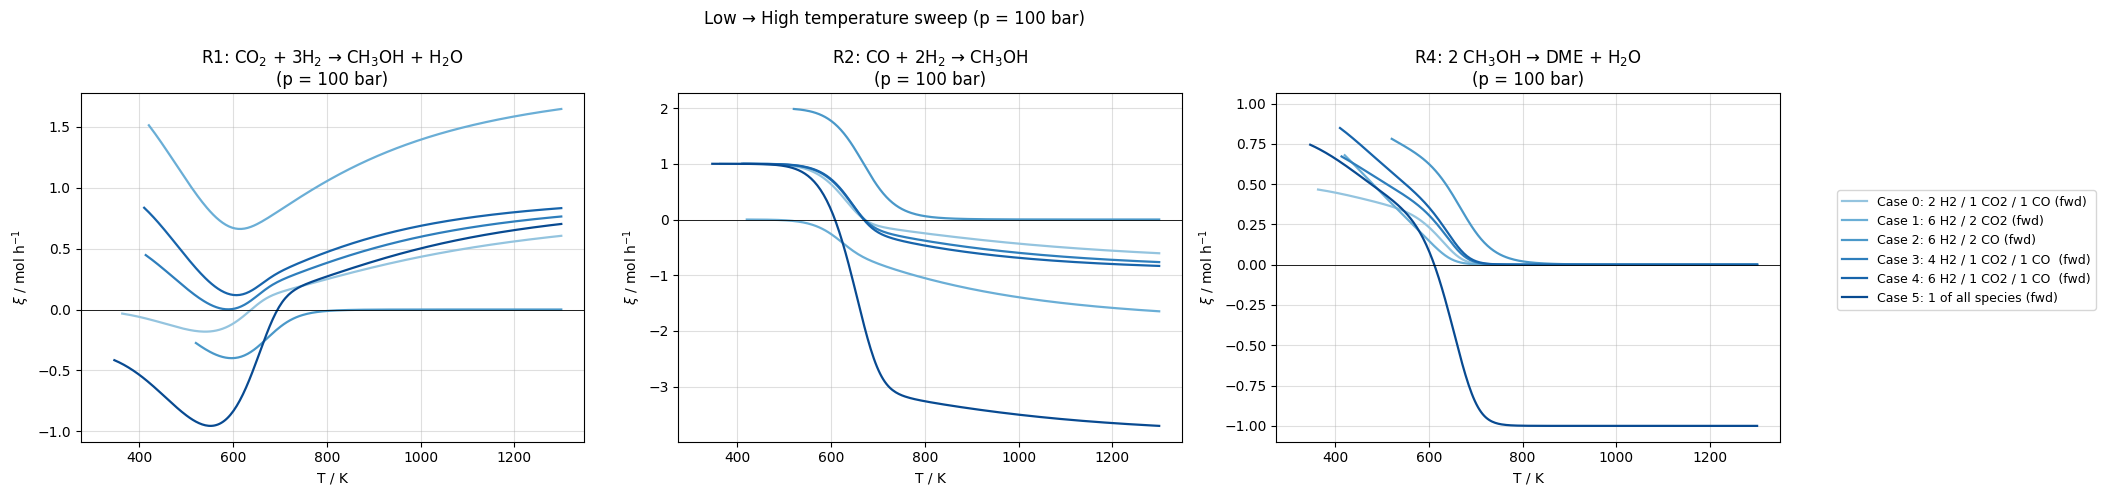

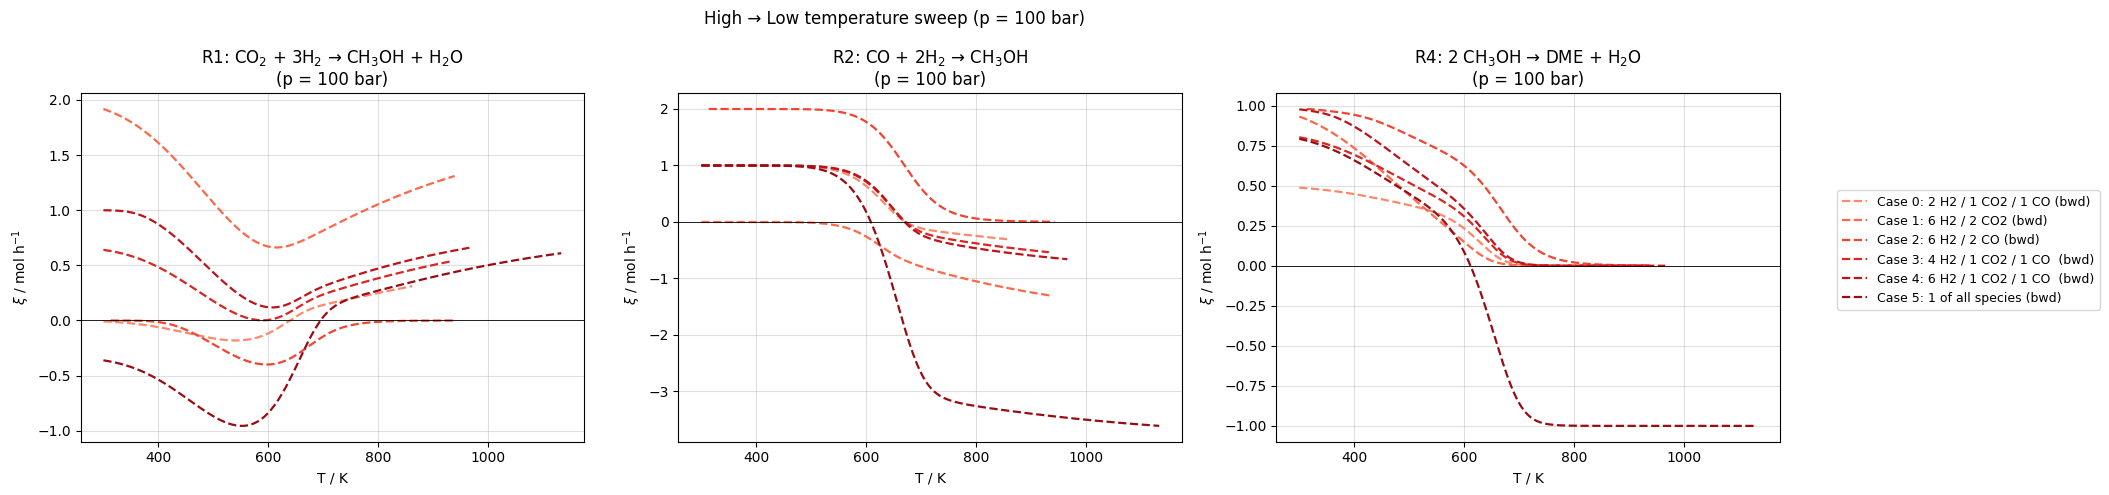

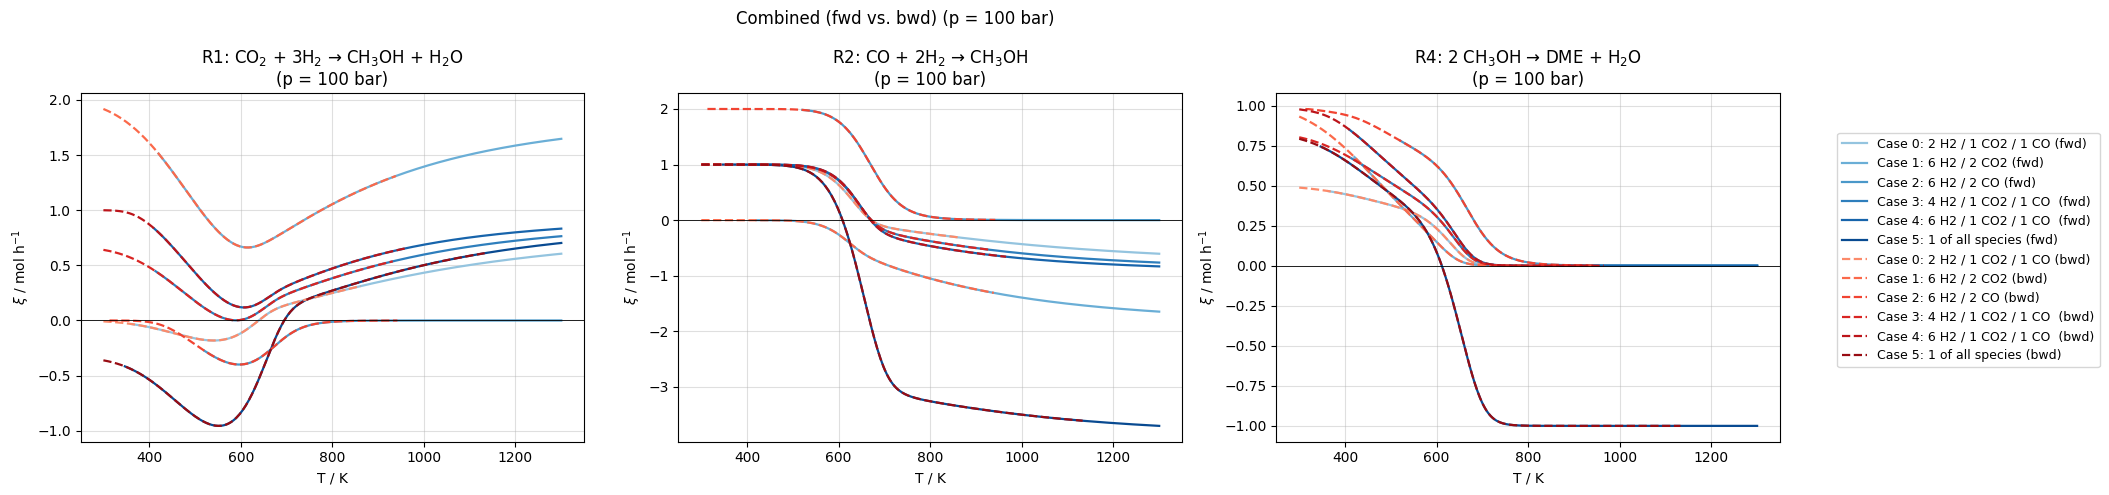

In [58]:
# =============================================================================
# ξ vs T at fixed pressure — forward (low→high) and backward (high→low) sweep
#
# Analogous to the pressure sweep, two temperature sweeps are computed to
# expose path-dependence in the nonlinear equilibrium solver:
#   - Forward sweep:  low T → high T, warm-started from the previous solution
#   - Backward sweep: high T → low T, warm-started from the previous solution
#
# Differences between the two curves indicate regions where the solver settles
# on different solution branches depending on the initial guess.
# =============================================================================

from matplotlib.lines import Line2D

# --- Temperature grid ---
# Uniform spacing across the full range of interest
T_range = np.linspace(300, 1300, 300)

p_fixed = 100  # bar — representative DME synthesis pressure

# --- Storage arrays for both sweep directions ---
# Shape: (n_cases, n_reactions, n_temperature_points)
xi_T_fwd = np.full((len(test_cases), 3, len(T_range)), np.nan)  # low T → high T
xi_T_bwd = np.full((len(test_cases), 3, len(T_range)), np.nan)  # high T → low T

# --- Forward sweep: low T → high T ---
for ci, (name, n_in) in enumerate(test_cases):
    xi_prev = make_initial_guess(n_in, reaction_indices, reaction_tuples)
    for ti, T in enumerate(T_range):
        xi = safe_solve(n_in, T, p_fixed, xi_init=xi_prev, xi_prev=xi_prev)
        if not np.any(np.isnan(xi)):
            xi_T_fwd[ci, :, ti] = xi
            xi_prev = xi  # warm-start next step from current solution

# --- Backward sweep: high T → low T ---
for ci, (name, n_in) in enumerate(test_cases):
    xi_prev = make_initial_guess(n_in, reaction_indices, reaction_tuples)
    for ti, T in enumerate(reversed(T_range)):
        xi = safe_solve(n_in, T, p_fixed, xi_init=xi_prev, xi_prev=xi_prev)
        if not np.any(np.isnan(xi)):
            xi_T_bwd[ci, :, len(T_range) - 1 - ti] = xi  # store at correct index
            xi_prev = xi

# --- Color and linestyle convention ---
# Separate colormaps for forward (Blues) and backward (Reds) sweep so that
# sweep direction is encoded by both color family and linestyle simultaneously.
colors_fwd = plt.cm.Blues(np.linspace(0.4, 0.9, len(test_cases)))
colors_bwd = plt.cm.Reds(np.linspace(0.4, 0.9, len(test_cases)))

sweep_colors = {'fwd': colors_fwd, 'bwd': colors_bwd}
sweep_ls     = {'fwd': '-',        'bwd': '--'}

# --- Plot configuration: three separate figures ---
plot_configs = [
    ('Low → High temperature sweep',      [(xi_T_fwd, 'fwd')]),
    ('High → Low temperature sweep',      [(xi_T_bwd, 'bwd')]),
    ('Combined (fwd vs. bwd)',             [(xi_T_fwd, 'fwd'), (xi_T_bwd, 'bwd')]),
]

for fig_title, sweep_configs in plot_configs:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for r_idx in range(3):
        for xi_data, sweep_label in sweep_configs:
            for ci, (name, n_in) in enumerate(test_cases):
                axes[r_idx].plot(
                    T_range, xi_data[ci, r_idx, :],
                    color=sweep_colors[sweep_label][ci],
                    linestyle=sweep_ls[sweep_label],
                    lw=1.6,
                )

        axes[r_idx].set_xlabel('T / K')
        axes[r_idx].set_ylabel(r'$\xi$ / mol h$^{-1}$')
        axes[r_idx].set_title(f'{reaction_labels_short[r_idx]}\n(p = {p_fixed} bar)')
        axes[r_idx].grid(True, alpha=0.4)
        axes[r_idx].axhline(0, color='k', lw=0.6)

    # --- Legend: only entries for sweeps actually shown in this figure ---
    legend_entries = []
    for xi_data, sweep_label in sweep_configs:
        for ci, (name, _) in enumerate(test_cases):
            legend_entries.append(
                Line2D([0], [0],
                       color=sweep_colors[sweep_label][ci],
                       linestyle=sweep_ls[sweep_label],
                       lw=1.6,
                       label=f'{name} ({sweep_label})')
            )

    fig.legend(
        handles=legend_entries,
        loc='center left', bbox_to_anchor=(1.02, 0.5),
        fontsize=9, frameon=True
    )
    fig.suptitle(f'{fig_title} (p = {p_fixed} bar)', fontsize=12)
    plt.tight_layout()
    plt.show()

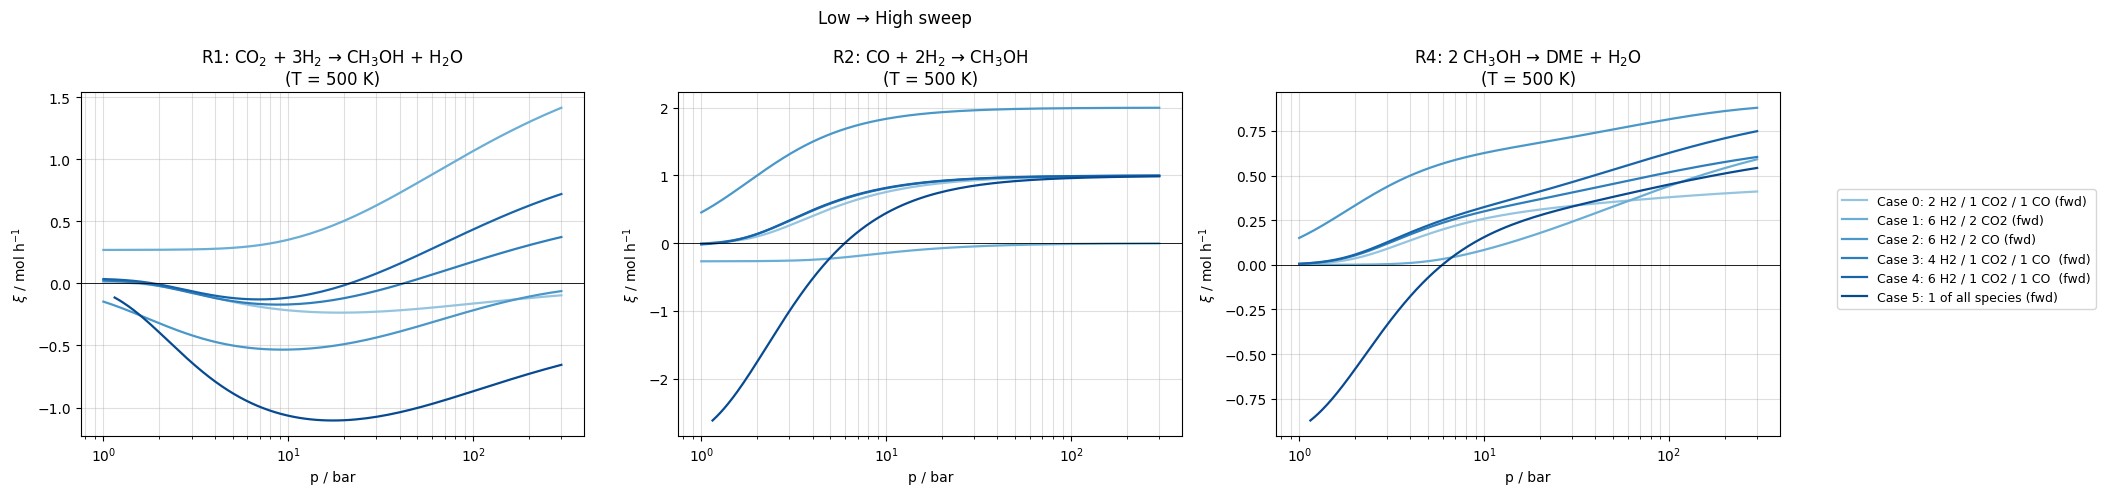

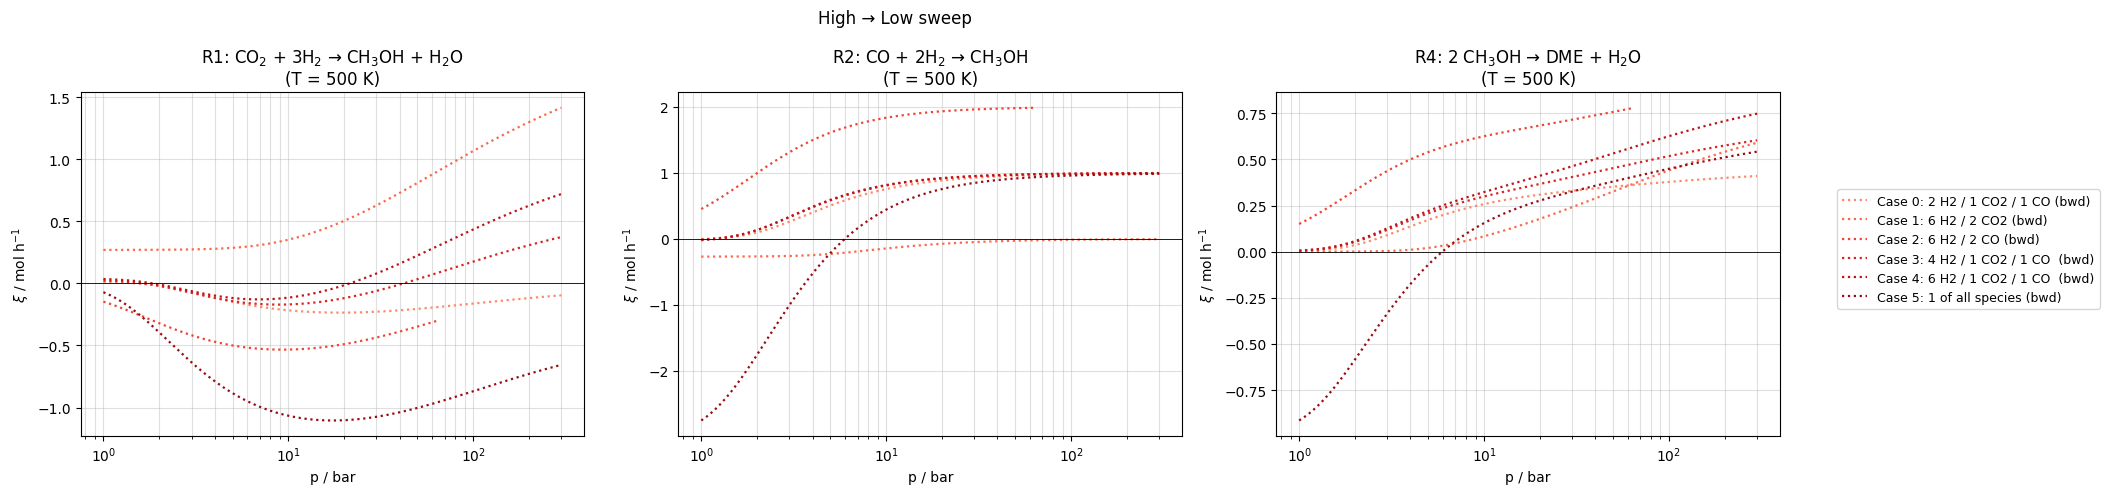

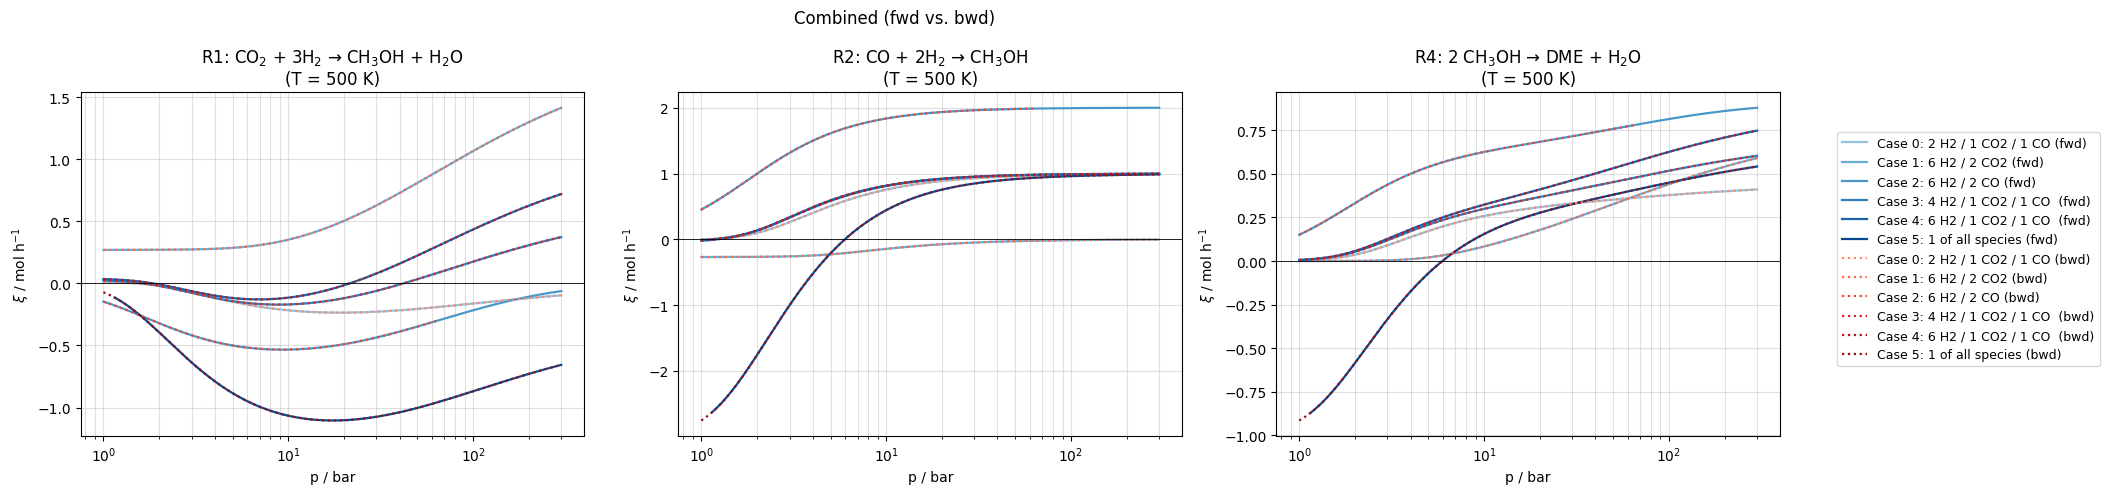

In [59]:
# =============================================================================
# ξ vs p at fixed temperature — forward (low→high) and backward (high→low) sweep
#
# Two separate pressure sweeps are computed to expose hysteresis / solver
# path-dependence (layover effect) in the nonlinear equilibrium system:
#   - Forward sweep:  low → high pressure, warm-started from the previous solution
#   - Backward sweep: high → low pressure, warm-started from the previous solution
#
# Differences between the two curves indicate regions where the solver settles
# on different solution branches depending on the initial guess, which points
# to multiple coexisting equilibrium solutions or poor solver convergence.
# =============================================================================

from matplotlib.lines import Line2D

# --- Pressure grid ---
# Dense resolution in the low-pressure region (1–10 bar) where nonlinear
# behaviour and potential discontinuities are most pronounced.
p_critical_region = np.linspace(1, 10, 300)
p_smooth_high     = np.logspace(np.log10(10), np.log10(300), 50)
p_range           = np.concatenate([p_critical_region[:-1], p_smooth_high])

T_fixed = 500  # K — representative DME synthesis temperature

# --- Storage arrays for both sweep directions ---
# Shape: (n_cases, n_reactions, n_pressure_points)
xi_p_fwd = np.full((len(test_cases), 3, len(p_range)), np.nan)  # low → high
xi_p_bwd = np.full((len(test_cases), 3, len(p_range)), np.nan)  # high → low

# --- Forward sweep: low → high pressure ---
for ci, (name, n_in) in enumerate(test_cases):
    xi_prev = make_initial_guess(n_in, reaction_indices, reaction_tuples)
    for pi, p in enumerate(p_range):
        xi = safe_solve(n_in, T_fixed, p, xi_init=xi_prev, xi_prev=xi_prev)
        if not np.any(np.isnan(xi)):
            xi_p_fwd[ci, :, pi] = xi
            xi_prev = xi  # warm-start next step from current solution

# --- Backward sweep: high → low pressure ---
for ci, (name, n_in) in enumerate(test_cases):
    xi_prev = make_initial_guess(n_in, reaction_indices, reaction_tuples)
    for pi, p in enumerate(reversed(p_range)):
        xi = safe_solve(n_in, T_fixed, p, xi_init=xi_prev, xi_prev=xi_prev)
        if not np.any(np.isnan(xi)):
            xi_p_bwd[ci, :, len(p_range) - 1 - pi] = xi  # store at correct index
            xi_prev = xi

# --- Color and linestyle convention ---
# Separate colormaps for forward (Blues) and backward (Reds) sweep so that
# sweep direction is encoded by both color family and linestyle simultaneously.
colors_fwd = plt.cm.Blues(np.linspace(0.4, 0.9, len(test_cases)))
colors_bwd = plt.cm.Reds(np.linspace(0.4, 0.9, len(test_cases)))

sweep_colors = {'fwd': colors_fwd, 'bwd': colors_bwd}
sweep_ls     = {'fwd': '-',        'bwd': ':'}

# --- Plot configuration: three separate figures ---
plot_configs = [
    ('Low → High sweep',          [(xi_p_fwd, 'fwd')]),
    ('High → Low sweep',          [(xi_p_bwd, 'bwd')]),
    ('Combined (fwd vs. bwd)',     [(xi_p_fwd, 'fwd'), (xi_p_bwd, 'bwd')]),
]

for fig_title, sweep_configs in plot_configs:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for r_idx in range(3):
        for xi_data, sweep_label in sweep_configs:
            for ci, (name, n_in) in enumerate(test_cases):
                axes[r_idx].plot(
                    p_range, xi_data[ci, r_idx, :],
                    color=sweep_colors[sweep_label][ci],
                    linestyle=sweep_ls[sweep_label],
                    lw=1.6,
                )

        axes[r_idx].set_xlabel('p / bar')
        axes[r_idx].set_ylabel(r'$\xi$ / mol h$^{-1}$')
        axes[r_idx].set_xscale('log')
        axes[r_idx].set_title(f'{reaction_labels_short[r_idx]}\n(T = {T_fixed} K)')
        axes[r_idx].grid(True, alpha=0.4, which='both')
        axes[r_idx].axhline(0, color='k', lw=0.6)

    # --- Legend: only entries for sweeps actually shown in this figure ---
    legend_entries = []
    for xi_data, sweep_label in sweep_configs:
        for ci, (name, _) in enumerate(test_cases):
            legend_entries.append(
                Line2D([0], [0],
                       color=sweep_colors[sweep_label][ci],
                       linestyle=sweep_ls[sweep_label],
                       lw=1.6,
                       label=f'{name} ({sweep_label})')
            )

    fig.legend(
        handles=legend_entries,
        loc='center left', bbox_to_anchor=(1.02, 0.5),
        fontsize=9, frameon=True
    )
    fig.suptitle(fig_title, fontsize=12)
    plt.tight_layout()
    plt.show()

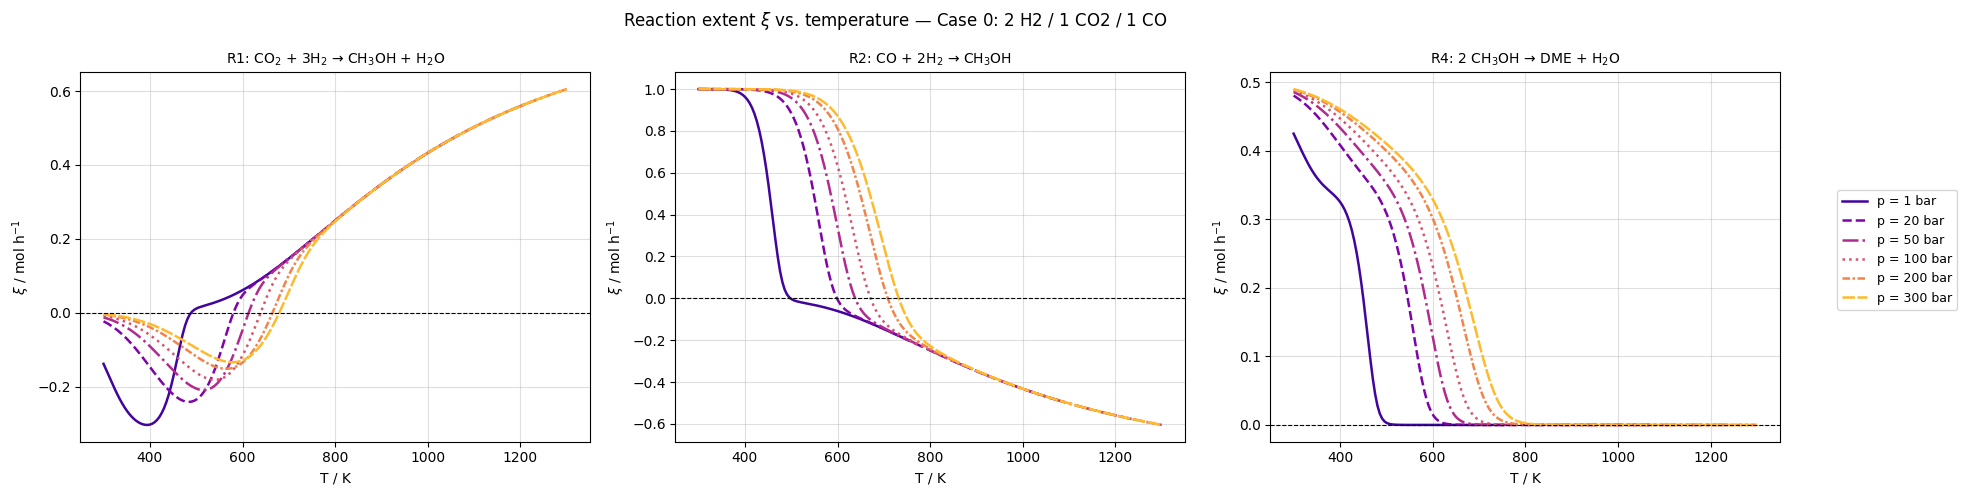

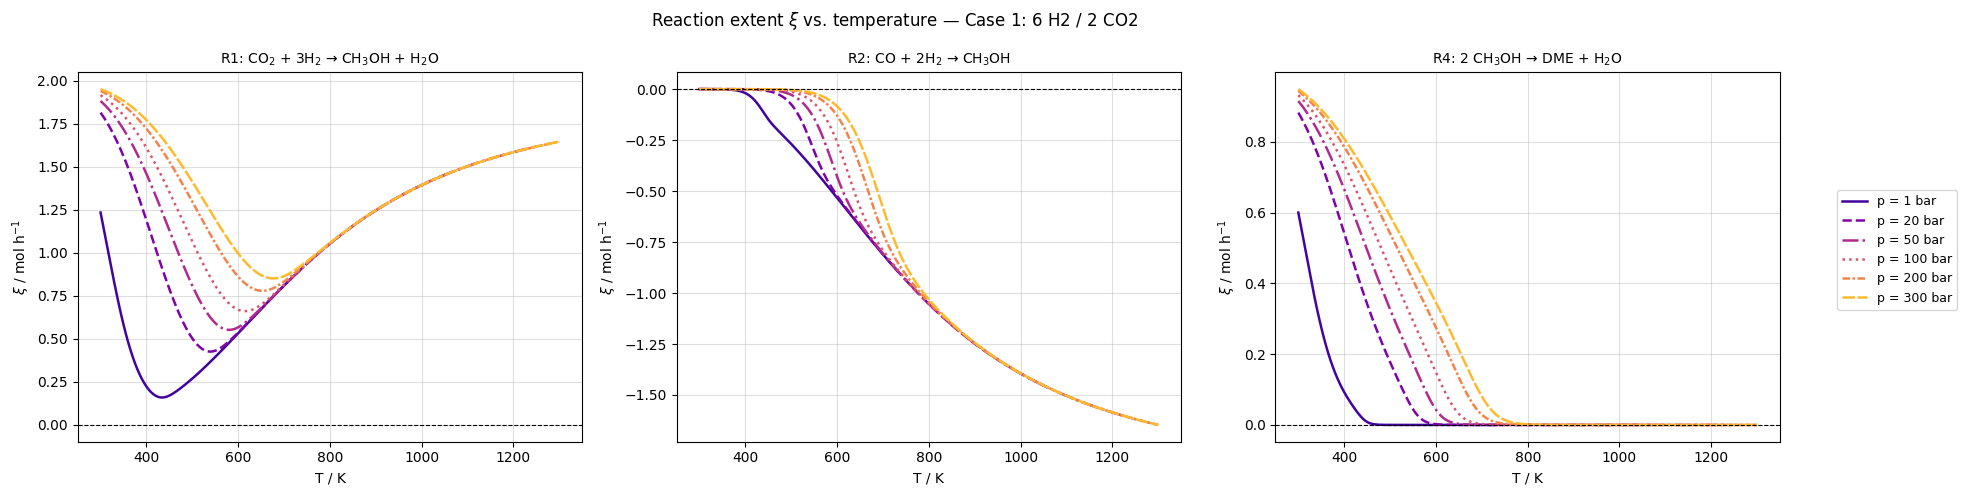

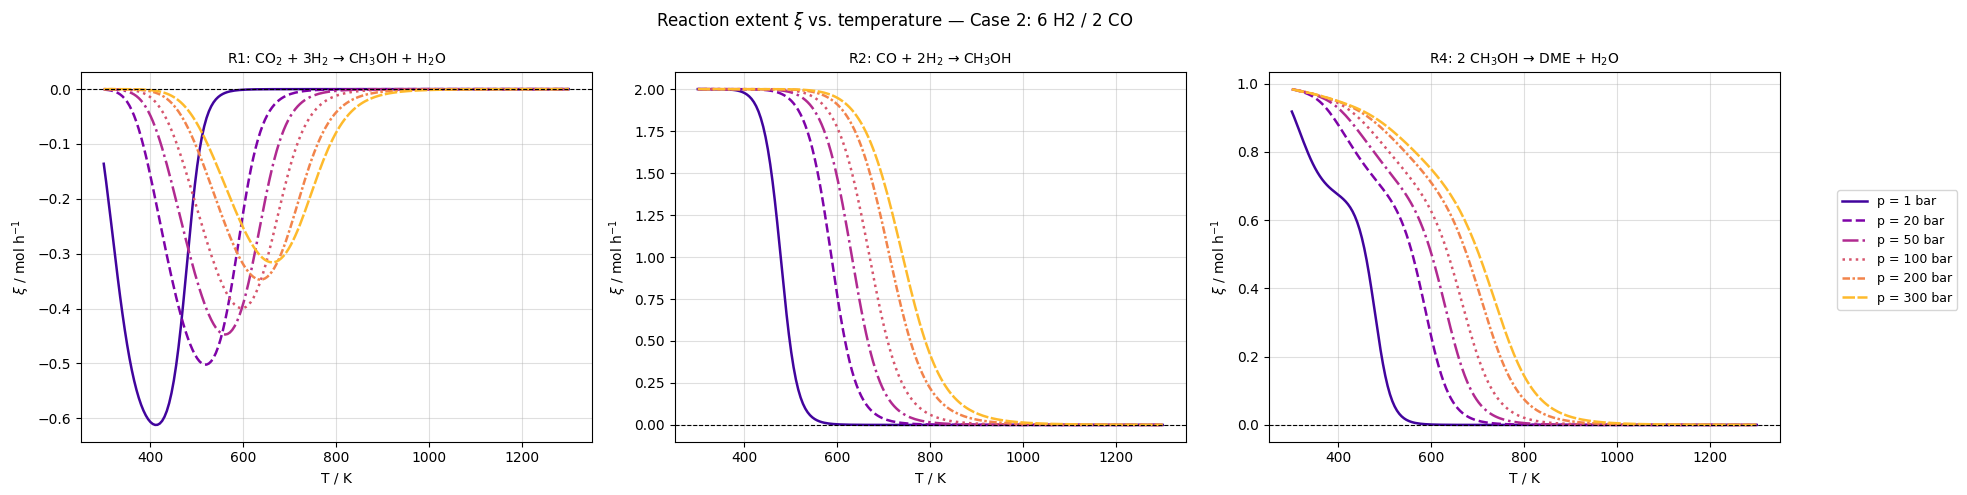

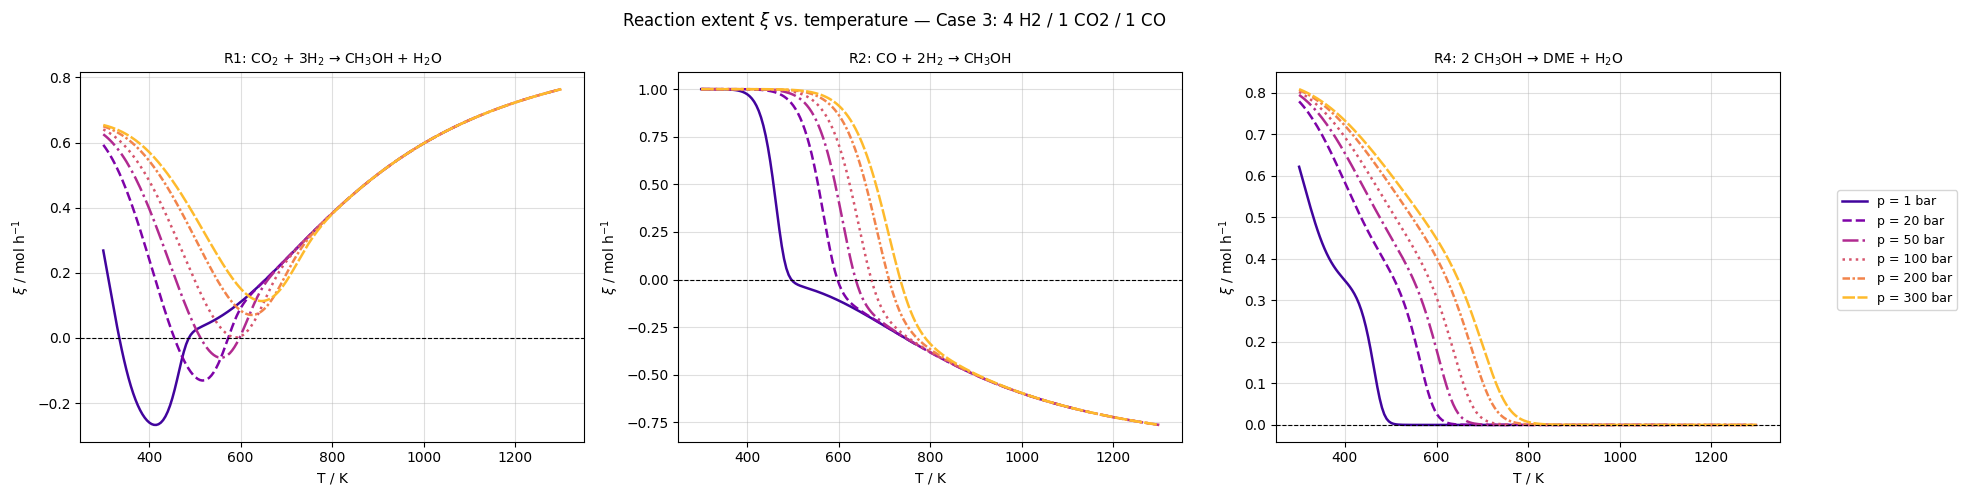

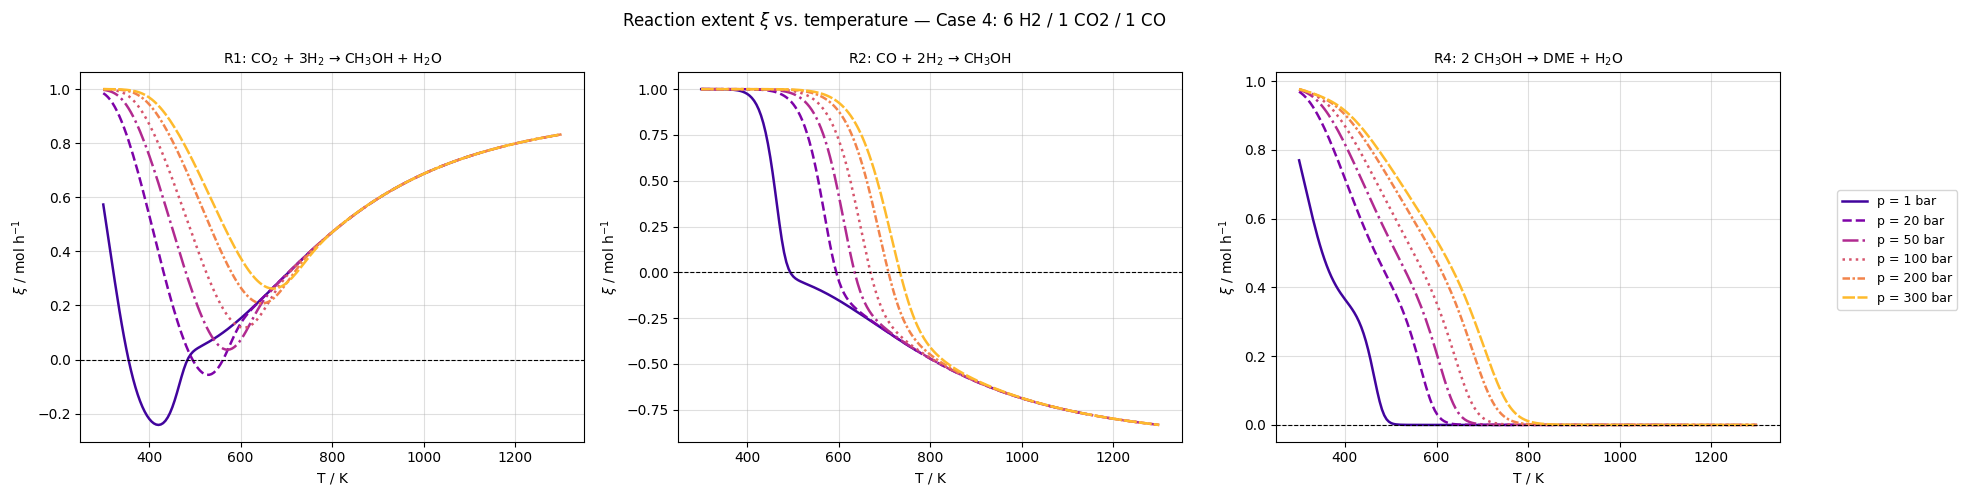

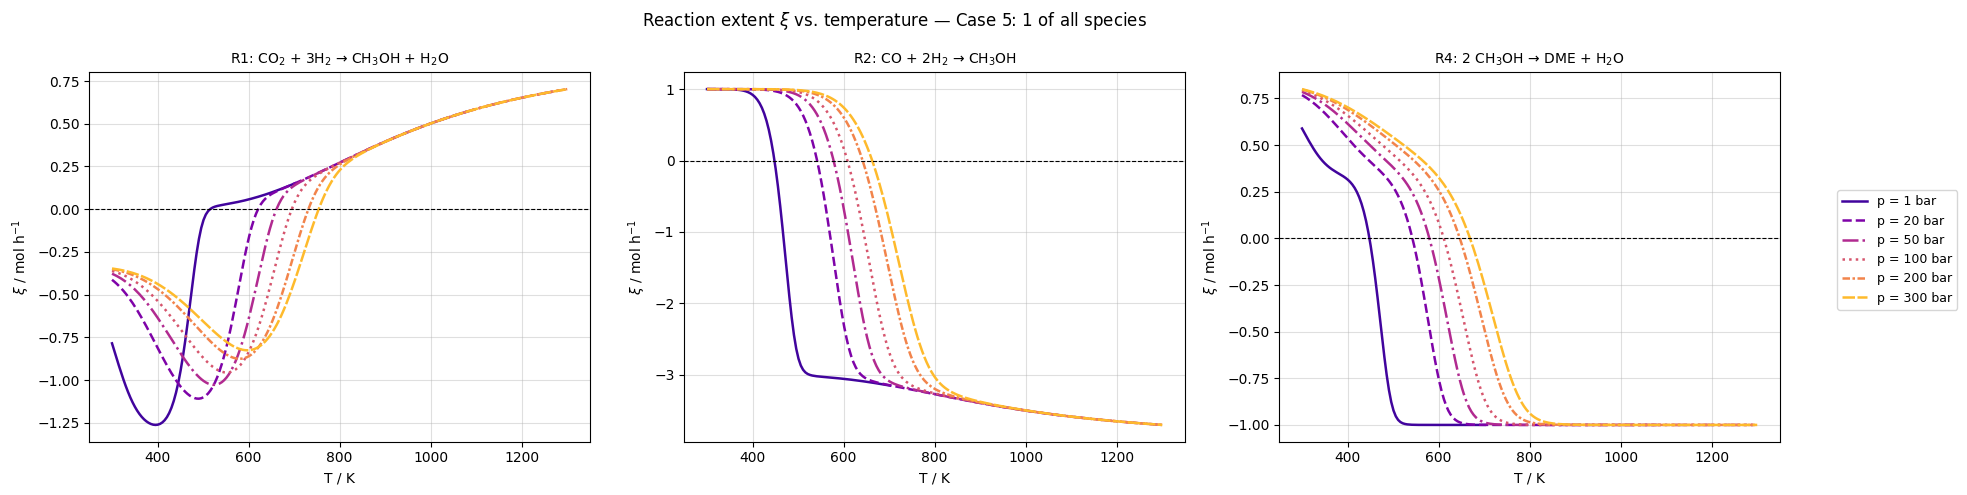

In [60]:
# =============================================================================
# ξ vs T at fixed pressures — 2D line plots for six pressure levels
#
# For each test case, one figure with 3 subplots (one per reaction) is shown.
# Each subplot contains six curves, one per pressure level.
# A single forward sweep (low T → high T) is used per pressure, warm-started
# from the previous temperature step for solver stability.
# =============================================================================

# --- Parameters ---
T_range_2d = np.linspace(300, 1300, 200)          # Temperature range [K]
pressures_2d = [1, 20, 50, 100, 200, 300]         # Pressure levels [bar]

# Distinguish pressure levels by both color and linestyle
p_colors_2d    = plt.cm.plasma(np.linspace(0.1, 0.85, len(pressures_2d)))
p_linestyles_2d = ['-', '--', '-.', ':', (0, (3,1,1,1)), (0, (5,1))]

# --- Compute ξ(T) for all cases and pressures — forward and backward sweep ---
# Shape: (n_cases, n_pressures, n_reactions, n_temperatures)
xi_2d = np.full((len(test_cases), len(pressures_2d), 3, len(T_range_2d)), np.nan)

for ci, (name, n_in) in enumerate(test_cases):
    for pi, p in enumerate(pressures_2d):

        # --- Forward sweep: low T → high T ---
        xi_prev = make_initial_guess(n_in, reaction_indices, reaction_tuples)
        for ti, T in enumerate(T_range_2d):
            xi = safe_solve(n_in, T, p, xi_init=xi_prev, xi_prev=xi_prev)
            if not np.any(np.isnan(xi)):
                xi_2d[ci, pi, :, ti] = xi
                xi_prev = xi

        # --- Backward sweep: high T → low T ---
        # Start from the last valid solution of the forward sweep instead of
        # make_initial_guess — this avoids a discontinuous jump at the right edge.
        last_valid = next(
            (xi_2d[ci, pi, :, ti] for ti in range(len(T_range_2d) - 1, -1, -1)
             if not np.any(np.isnan(xi_2d[ci, pi, :, ti]))),
            make_initial_guess(n_in, reaction_indices, reaction_tuples)
        )
        xi_prev = last_valid

        for ti, T in enumerate(reversed(T_range_2d)):
            real_ti = len(T_range_2d) - 1 - ti
            if not np.any(np.isnan(xi_2d[ci, pi, :, real_ti])):
                xi_prev = xi_2d[ci, pi, :, real_ti]
                continue
            xi = safe_solve(n_in, T, p, xi_init=xi_prev, xi_prev=xi_prev)
            if not np.any(np.isnan(xi)):
                xi_2d[ci, pi, :, real_ti] = xi
                xi_prev = xi

# --- Plotting: one figure per test case ---
for ci, (name, n_in) in enumerate(test_cases):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for r_idx in range(3):
        ax = axes[r_idx]

        for pi, p in enumerate(pressures_2d):
            ax.plot(
                T_range_2d,
                xi_2d[ci, pi, r_idx, :],
                color=p_colors_2d[pi],
                linestyle=p_linestyles_2d[pi],
                linewidth=1.8,
                label=f'p = {p} bar'
            )

        ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
        ax.set_xlabel('T / K', fontsize=10)
        ax.set_ylabel(r'$\xi$ / mol h$^{-1}$', fontsize=10)
        ax.set_title(f'{reaction_labels_short[r_idx]}', fontsize=10)
        ax.grid(True, alpha=0.4)

    # Shared legend to the right
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles, labels,
        loc='center left', bbox_to_anchor=(1.02, 0.5),
        fontsize=9, frameon=True
    )
    fig.suptitle(f'Reaction extent $\\xi$ vs. temperature — {name}', fontsize=12)
    plt.tight_layout()
    plt.show()

# 7. Calculation of the Yield

To evaluate the overall process performance, the yield of the target product, dimethyl ether ($Y_{DME}$), is determined with respect to the total carbon oxide feed, defined as the combined inlet molar flow of $\mathrm{CO}$ and $\mathrm{CO}_2$ ($\dot{n}_{COx,in} = \dot{n}_{CO,in} + \dot{n}_{CO_2,in}$). This normalization ensures that the yield is directly comparable across all feed compositions investigated, regardless of whether the carbon source is purely $\mathrm{CO}_2$, purely $\mathrm{CO}$, or a mixture of both.

By combining the individual reaction steps of the network, two global stoichiometric equations for direct DME synthesis can be formulated, one for each carbon source:

$$2\,\mathrm{CO_2} + 6\,\mathrm{H_2} \rightleftharpoons \mathrm{CH_3OCH_3} + 3\,\mathrm{H_2O} \tag{23}$$

$$2\,\mathrm{CO} + 4\,\mathrm{H_2} \rightleftharpoons \mathrm{CH_3OCH_3} + \mathrm{H_2O} \tag{24}$$

In both cases, the stoichiometric ratio of carbon oxide to DME is $|\nu_{COx}| / |\nu_{DME}| = 2$, so a single unified yield expression applies regardless of feed composition:

$$Y_{DME} = \frac{|\nu_{COx}|}{|\nu_{DME}|} \cdot \frac{\dot{n}_{DME,out} - \dot{n}_{DME,in}}{\dot{n}_{COx,in}} = 2 \cdot \frac{\dot{n}_{DME,out} - \dot{n}_{DME,in}}{\dot{n}_{CO,in} + \dot{n}_{CO_2,in}} \tag{25}$$

To verify this implementation, a standard reference scenario (Case 0) was evaluated using a stoichiometric feed ratio of 18 mol/h $\mathrm{H_2}$ and 6 mol/h $\mathrm{CO_2}$. At an industrially relevant operating condition of 500 K and 100 bar, the numerical solver computed a final DME production of 1.3227 mol/h. This corresponds to an equilibrium yield of 44.09%. This result demonstrates that even under highly favorable high-pressure and low-temperature conditions, the maximum achievable product yield remains strictly limited by the chemical equilibrium of the reaction network.

In [61]:
def dme_yield(n_in, n_out):
    """
    Calculate the DME yield with respect to total carbon oxide (COx) feed.
    COx is defined as the sum of CO and CO2 in the inlet stream.

    The normalization accounts for all carbon-containing feed species,
    making the yield comparable across feeds of pure CO, pure CO2, or mixtures.

    Overall reactions contributing to DME formation:
        From CO2:  2 CO2 + 6 H2  → DME + 3 H2O   (nu_COx = 2, nu_DME = 1)
        From CO:   2 CO  + 4 H2  → DME + H2O      (nu_COx = 2, nu_DME = 1)

    In both cases the stoichiometric ratio nu_COx / nu_DME = 2, so the
    normalization factor is the same regardless of feed composition.

    Y_DME = (nu_COx / nu_DME) * (n_DME_out - n_DME_in) / n_COx_in
          = 2 * (n_DME_out - n_DME_in) / (n_CO_in + n_CO2_in)

    Parameters
    ----------
    n_in  : array - inlet molar flow [mol/h],  order: [CO, CO2, DME, H2, H2O, CH3OH]
    n_out : array - outlet molar flow [mol/h], order: [CO, CO2, DME, H2, H2O, CH3OH]

    Returns
    -------
    Y_DME : float - DME yield [-], or np.nan if no COx in feed
    """
    nu_COx = 2.0
    nu_DME = 1.0

    n_CO_in   = n_in[0]   # index 0 = CO
    n_CO2_in  = n_in[1]   # index 1 = CO2
    n_DME_in  = n_in[2]   # index 2 = DME
    n_DME_out = n_out[2]  # index 2 = DME

    # Total carbon oxide feed — normalization basis
    n_COx_in = n_CO_in + n_CO2_in

    if n_COx_in <= 0:
        return np.nan  # yield undefined if no carbon oxide in feed

    return (nu_COx / nu_DME) * (n_DME_out - n_DME_in) / n_COx_in

In [62]:
# --- Test: DME yield for Case 0 at T=500K, p=100bar ---
name, n_in = test_cases[0]
xi, sol = root_solver(reaction_tuples, list(make_initial_guess(n_in, reaction_indices, reaction_tuples)), n_in, 500, 100, reaction_indices)
n_out = material_balance(reaction_tuples, xi, n_in, reaction_indices)

Y = dme_yield(n_in, n_out)
print(f"{name}")
print(f"  n_in:  {n_in}")
print(f"  n_out: {np.round(n_out, 4)}")
print(f"  Y_DME: {Y:.4f}")

Case 0: 2 H2 / 1 CO2 / 1 CO
  n_in:  [1. 1. 0. 2. 0. 0.]
  n_out: [0.0207 1.1623 0.3784 0.5283 0.2162 0.0601]
  Y_DME: 0.3784


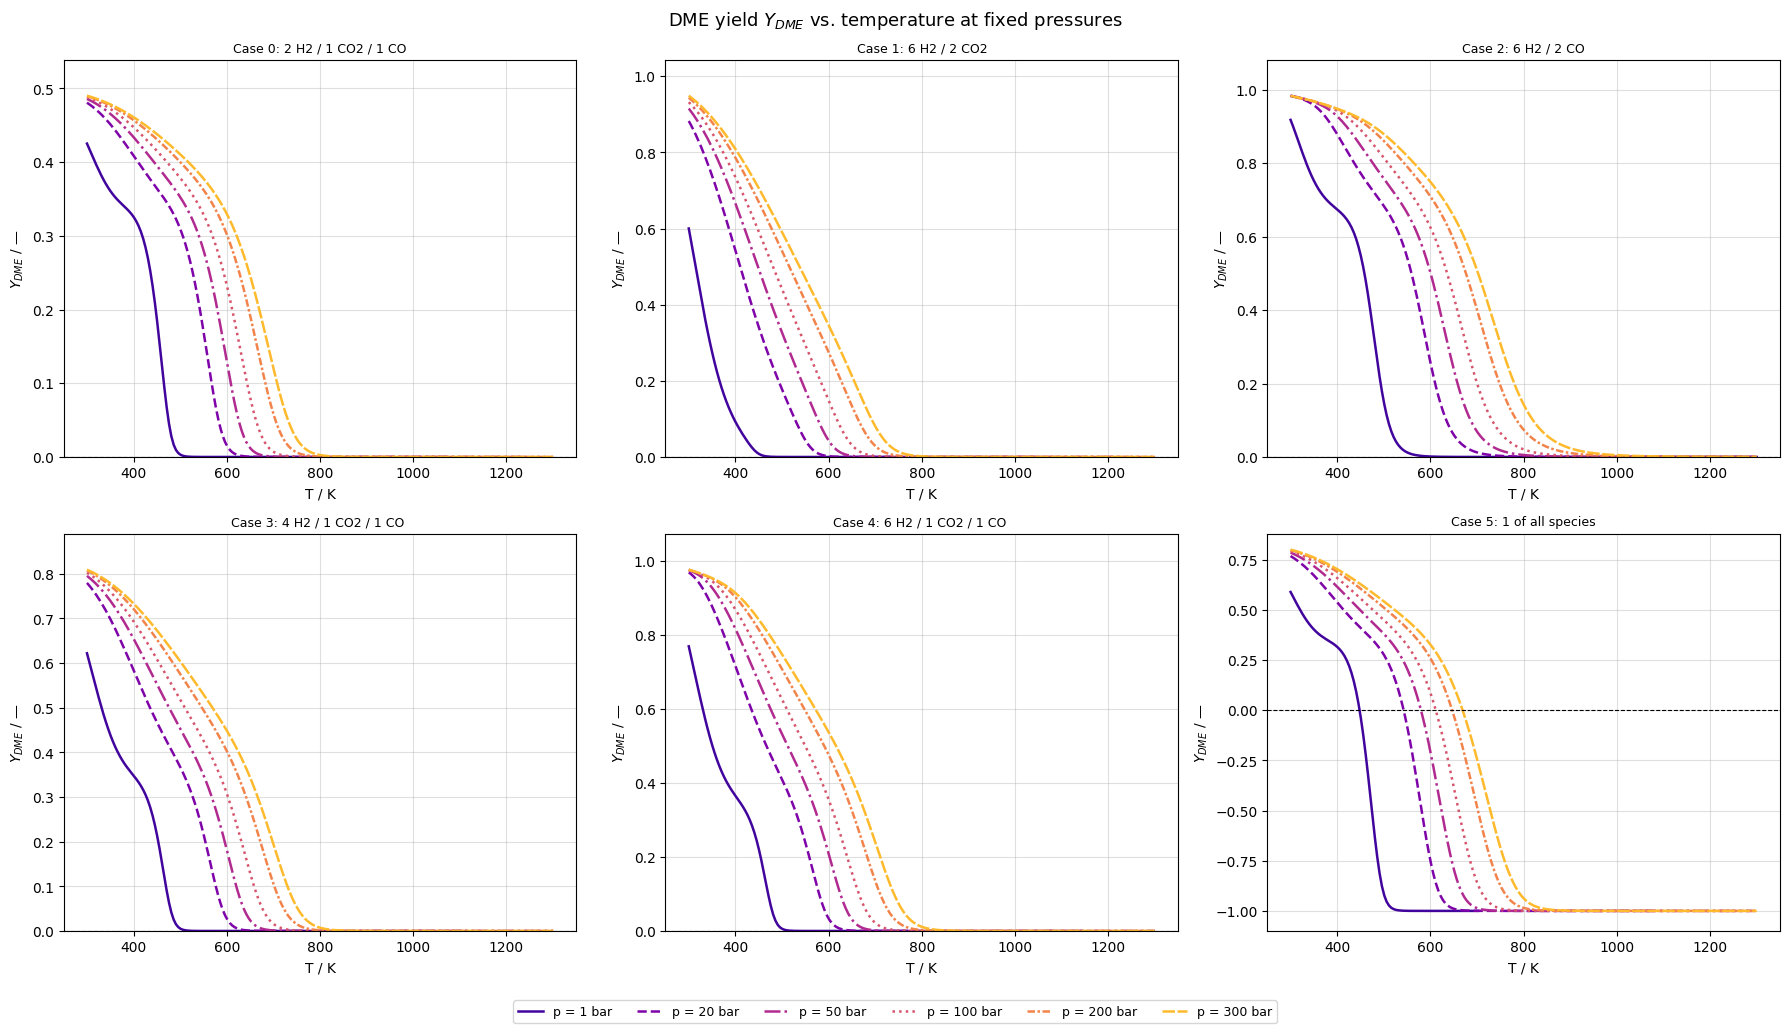

In [66]:
# =============================================================================
# Y_DME vs T at fixed pressures — 2x3 subplot grid, one panel per test case
#
# Computed directly from the already calculated xi_2d array, so no additional
# solver calls are needed. The DME yield is calculated using the COx-normalised
# dme_yield() function defined earlier.
# =============================================================================

# --- Compute Y_DME for all cases and pressures from existing xi_2d ---
# Shape: (n_cases, n_pressures, n_temperatures)
Y_DME_2d = np.full((len(test_cases), len(pressures_2d), len(T_range_2d)), np.nan)

for ci, (name, n_in) in enumerate(test_cases):
    for pi, p in enumerate(pressures_2d):
        for ti in range(len(T_range_2d)):
            xi = xi_2d[ci, pi, :, ti]
            if np.any(np.isnan(xi)):
                continue
            n_out = material_balance(reaction_tuples, xi, n_in, reaction_indices)
            Y_DME_2d[ci, pi, ti] = dme_yield(n_in, n_out)

# --- Plotting: 2 rows x 3 cols grid, one subplot per test case ---
n_cols = 3
n_rows = 2

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 10), sharey=False)
axes = axes.flatten()

for ci, (name, n_in) in enumerate(test_cases):
    ax = axes[ci]

    for pi, p in enumerate(pressures_2d):
        ax.plot(
            T_range_2d,
            Y_DME_2d[ci, pi, :],
            color=p_colors_2d[pi],
            linestyle=p_linestyles_2d[pi],
            linewidth=1.8,
            label=f'p = {p} bar'
        )

    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xlabel('T / K', fontsize=10)
    ax.set_ylabel(r'$Y_{DME}$ / —', fontsize=10)
    ax.set_title(name, fontsize=9)
    ax.grid(True, alpha=0.4)

    # Set y-axis limits individually per case to ensure all values are visible
    y_max = np.nanmax(Y_DME_2d[ci, :, :])
    y_min = np.nanmin(Y_DME_2d[ci, :, :])
    # Use 0 as lower bound unless negative values are present
    ax.set_ylim(min(0, y_min * 1.1), y_max * 1.1)

# Hide unused subplots if n_cases < 6
for ci in range(len(test_cases), n_rows * n_cols):
    axes[ci].set_visible(False)

# Shared legend at the bottom, horizontal layout
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc='lower center', bbox_to_anchor=(0.5, -0.04),
    ncol=len(pressures_2d), fontsize=9, frameon=True
)

fig.suptitle(r'DME yield $Y_{DME}$ vs. temperature at fixed pressures', fontsize=13)
plt.tight_layout()
plt.show()

Here in the cases 6 to 9 the conditions of K.L. Ng et al. [7] are simulated with a Temperature of 523 K, 50 bar and a $H_2$ / $CO_2$ ratio varying from 1 to 4. Y_DME shows the resulting DME yield of each case, ranging from 8,86 % to 31,64 %. 

In [ ]:
# # ====================== 3D-Surface: Y_DME(T,p) for all test cases ======================

# # NOTE: for this plot to work, xi_TP_all must be fully computed from the previous section. If you encounter NaNs in Y_DME, ensure that the solver successfully computed xi for all T,p points.

# ##################### I added more test cases :-) - Max


# # --- Compute Y_DME for all cases from already calculated xi_TP_all ---
# Y_DME_all = np.full((n_cases, len(p_3d), len(T_3d)), np.nan)

# for ci, (name, n_in) in enumerate(test_cases):
#     for pi in range(len(p_3d)):
#         for ti in range(len(T_3d)):
#             xi = xi_TP_all[ci, :, pi, ti]
#             if np.any(np.isnan(xi)):
#                 continue
#             n_out = material_balance(reaction_tuples, xi, n_in, reaction_indices)
#             Y_DME_all[ci, pi, ti] = dme_yield(n_in, n_out)

# # --- Global color scale across all cases ---
# vmin_Y = np.nanmin(Y_DME_all)
# vmax_Y = np.nanmax(Y_DME_all)

# z_plane = np.zeros_like(T_mesh)

# # --- Static 3D Plot: 3 cols x 2 rows grid ---
# n_cols = 3
# n_rows = 4  # ceil(5/3) = 2

# fig, axes = plt.subplots(
#     n_rows, n_cols,
#     figsize=(18, 10),
#     subplot_kw={'projection': '3d'}
# )

# for ci, (name, n_in) in enumerate(test_cases):
#     row = ci // n_cols
#     col = ci  % n_cols
#     ax  = axes[row, col]

#     surf = ax.plot_surface(
#         T_mesh, p_mesh, Y_DME_all[ci],
#         cmap='viridis', alpha=0.9, edgecolor='none',
#         vmin=vmin_Y, vmax=vmax_Y
#     )
#     ax.plot_surface(
#         T_mesh, p_mesh, z_plane,
#         alpha=0.2, color='gray', edgecolor='none'
#     )
#     ax.set_xlabel('T / K', fontsize=8)
#     ax.set_ylabel('p / bar', fontsize=8)
#     ax.set_zlabel(r'$Y_{DME}$ / -', fontsize=8)
#     ax.set_title(f'DME Yield\n{name}', fontsize=9)
#     ax.set_xlim([T_3d.min(), T_3d.max()])
#     ax.set_ylim([p_3d.min(), p_3d.max()])
#     ax.set_zlim([vmin_Y, vmax_Y])
#     fig.colorbar(surf, ax=ax, shrink=0.5, pad=0.1)

# # Hide unused subplot (6th cell, index 5)
# if n_cases < n_rows * n_cols:
#     for empty in range(n_cases, n_rows * n_cols):
#         axes[empty // n_cols, empty % n_cols].set_visible(False)

# plt.tight_layout()
# plt.show()

IndexError: index 100 is out of bounds for axis 3 with size 100

## 7.1. Interactive 3D Surface Mapping of the DME Yield

To gain a comprehensive overview of process efficiency, the equilibrium yield of dimethyl ether ($Y_{DME}$) was mapped as a 3D surface across the temperature and pressure range for all tested cases. This interactive framework provides a direct comparison of how different initial mixtures influence the overall product yield. Each surface allows for precise, point-by-point data extraction, enabling the identification of specific operating points that maximize the DME yield. 

The results consistently demonstrate that the reaction yield is strongly constrained by the underlying chemical equilibrium. As observed in the 3D topographies, the equilibrium yield is limited at high temperatures, confirming the exothermic nature of the reaction network. Conversely, elevated pressures effectively shift the equilibrium toward the target product, highlighting the critical importance of selecting high-pressure operating conditions for industrial-scale reactor design. By visualizing these multi-dimensional effects for every tested case, the optimal operating window can be identified not just theoretically, but practically for a wide range of potential feed scenarios.

In [ ]:
# import math
# # ====================== Interactive 3D-Surface: Y_DME(T,p) for all test cases ======================

# n_cols = 3
# n_rows = math.ceil(n_cases / n_cols)

# fig = make_subplots(
#     rows=n_rows, cols=n_cols,
#     specs=[[{'type': 'surface'} for _ in range(n_cols)] for _ in range(n_rows)],
#     subplot_titles=[name for name, _ in test_cases]
# )

# for ci, (name, n_in) in enumerate(test_cases):
#     row = ci // n_cols + 1  # plotly is 1-indexed
#     col = ci  % n_cols + 1

#     fig.add_trace(
#         go.Surface(
#             x=T_mesh[0],
#             y=p_mesh[:, 0],
#             z=Y_DME_all[ci],
#             colorscale='Viridis',
#             cmin=vmin_Y,
#             cmax=vmax_Y,
#             showscale=(ci == n_cases - 1),  # colorbar only on last plot
#             colorbar=dict(x=1.02, len=0.7) if ci == n_cases - 1 else None,
#             name=name,
#             hovertemplate='T: %{x:.0f} K<br>p: %{y:.1f} bar<br>Y_DME: %{z:.4f}<extra></extra>'
#         ),
#         row=row, col=col
#     )

# # --- Set axis labels for all scenes ---
# scene_idx = 1
# for ci in range(n_cases):
#     key = 'scene' if scene_idx == 1 else f'scene{scene_idx}'
#     fig.update_layout(**{
#         key: dict(
#             xaxis=dict(title='T / K', range=[T_3d.min(), T_3d.max()]),
#             yaxis=dict(title='p / bar', range=[p_3d.min(), p_3d.max()]),
#             zaxis=dict(title='Y_DME / -', range=[vmin_Y, vmax_Y]),
#             camera=dict(eye=dict(x=1.5, y=1.5, z=1.3))
#         )
#     })
#     scene_idx += 1

# fig.update_layout(
#     title_text='Interactive 3D Surface: Y_DME(T,p) for all test cases',
#     width=1800,
#     height=600 * n_rows,
#     showlegend=False,
#     hovermode='closest'
# )

# fig.show()

# T_eval_1999 = 523.15  # K (250°C)
# p_eval_1999 = 50       # bar
# cases = [0, 1, 2, 3]  # Indices of test cases to evaluate
# eval_with_1999_paper_yields = []
# for index in cases:
#     case_name, n_in = test_cases[index]
#     xi = safe_solve(n_in, T_eval_1999, p_eval_1999)
#     n_out = material_balance(reaction_tuples, xi, n_in, reaction_indices)
#     Y = dme_yield(n_in, n_out)
#     eval_with_1999_paper_yields.append(Y)
#     print(f"{case_name}: Y_DME(250°C, 50 bar) = {Y:.4f}")

Case 0: 18 H2 / 6 CO2: Y_DME(250°C, 50 bar) = 0.2555
Case 1: 12 H2 / 4 CO2: Y_DME(250°C, 50 bar) = 0.2555
Case 2: 6 H2 / 2 CO2: Y_DME(250°C, 50 bar) = 0.2555
Case 3: 6 H2 / 2 CO2 / 1 CO / 1 H2O: Y_DME(250°C, 50 bar) = 0.3114


# Graveyard of Code

In [ ]:
# # ====================== ξ vs p (for a fixed T) ======================
# p_critical_region = np.linspace(1, 10, 300)
# p_smooth_high = np.logspace(np.log10(10), np.log10(300), 50)
# p_range = np.concatenate([p_critical_region[:-1], p_smooth_high])
# T_fixed = 500

# xi_p = np.full((len(test_cases), 3, len(p_range)), np.nan)

# for ci, (name, n_in) in enumerate(test_cases):
#     # Solve high-to-low: warm-start from high pressure where solver is stable
#     xi_prev = make_initial_guess(n_in, reaction_indices, reaction_tuples)
    
#     for pi, p in enumerate(reversed(p_range)):
#         xi = safe_solve(n_in, T_fixed, p, xi_init=xi_prev, xi_prev=xi_prev)
#         if not np.any(np.isnan(xi)):
#             xi_prev = xi
#             # Store at correct index (reversed)
#             xi_p[ci, :, len(p_range) - 1 - pi] = xi

# # --- Plotting (unchanged) ---
# colors = plt.cm.rainbow(np.linspace(0, 1, len(test_cases)))

# fig, axes = plt.subplots(1, 3, figsize=(18, 5))
# for r_idx in range(3):
#     for ci, (name, n_in) in enumerate(test_cases):
#         axes[r_idx].plot(p_range, xi_p[ci, r_idx, :], label=name, lw=1.6, color=colors[ci])
#     axes[r_idx].set_xlabel('p / bar')
#     axes[r_idx].set_ylabel(r'$\xi$ / mol h$^{-1}$')
#     axes[r_idx].set_xscale('log')
#     axes[r_idx].set_title(f'{reaction_labels_short[r_idx]}\n(T = {T_fixed} K)')
#     axes[r_idx].grid(True, alpha=0.4, which='both')
#     axes[r_idx].axhline(0, color='k', lw=0.6)

# handles, labels = axes[0].get_legend_handles_labels()
# fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=9, frameon=True)

# plt.tight_layout()
# plt.show()

In [ ]:
# # ====================== ξ vs p (for a fixed T) ======================
# # p_range  = np.logspace(0, np.log10(300), 100)  # 1 ... 300 bar, log-scaled
# p_critical_region = np.linspace(1, 10, 300)   # ← Bereich mit Struktur, 300 Punkte
# # p_smooth_low  = np.logspace(0, np.log10(5), 30)    # 1-5 bar, 30 Punkte
# p_smooth_high = np.logspace(np.log10(10), np.log10(300), 50)  # 20-300 bar, 50 Punkte

# p_range = np.concatenate([p_critical_region[:-1], p_smooth_high])
# T_fixed  = 500  # K — typical for dme synthesis, can be changed to your needs

# xi_p = np.full((len(test_cases), 3, len(p_range)), np.nan)

# for ci, (name, n_in) in enumerate(test_cases):
#     xi_prev = make_initial_guess(n_in, reaction_indices, reaction_tuples)
#     for pi, p in enumerate(p_range):
#         xi = safe_solve(n_in, T_fixed, p, xi_init=xi_prev, xi_prev=xi_prev)
#         if not np.any(np.isnan(xi)):
#             xi_p[ci, :, pi] = xi
#             xi_prev = xi

# # Define colors from rainbow colormap for consistent appearance across all plots
# colors = plt.cm.rainbow(np.linspace(0, 1, len(test_cases)))

# fig, axes = plt.subplots(1, 3, figsize=(18, 5))
# for r_idx in range(3):
#     for ci, (name, n_in) in enumerate(test_cases):
#         axes[r_idx].plot(p_range, xi_p[ci, r_idx, :], label=name, lw=1.6, color=colors[ci])
#     axes[r_idx].set_xlabel('p / bar')
#     axes[r_idx].set_ylabel(r'$\xi$ / mol h$^{-1}$')
#     axes[r_idx].set_xscale('log')
#     axes[r_idx].set_title(f'{reaction_labels_short[r_idx]}\n(T = {T_fixed} K)')
#     axes[r_idx].grid(True, alpha=0.4, which='both')
#     axes[r_idx].axhline(0, color='k', lw=0.6)

# # Single legend positioned to the right of all plots
# handles, labels = axes[0].get_legend_handles_labels()
# fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=9, frameon=True)

# plt.tight_layout()
# plt.show()

In [ ]:
# # =============================================================================
# # ξ(T, p) 3D surface — optimised for speed via joblib parallelisation
# #
# # Key changes vs. the original:
# #   1. Reduced grid resolution (30×30) to limit solver calls per case.
# #   2. Parallelisation over test cases via joblib.Parallel — each case is
# #      independent and can run on a separate CPU core.
# #   3. Original four-directional sweep preserved to avoid NaN gaps:
# #        Pass 1: high-p → low-p, high-T → low-T
# #        Pass 2: low-p → high-p, low-T → high-T  (fills remaining gaps)
# # =============================================================================

# from joblib import Parallel, delayed

# # --- Grid resolution ---
# # 200×200 = 40000 points per sweep direction, 160000 total solver calls per case
# N_T = 200
# N_P = 200

# T_3d = np.linspace(300, 2000, N_T)
# p_3d = np.logspace(0, np.log10(300), N_P)
# T_mesh, p_mesh = np.meshgrid(T_3d, p_3d)
# n_cases = len(test_cases)

# def compute_case(ci_name_nin):
#     """
#     Compute xi(T, p) for a single test case using four directional sweeps.
#     Each subsequent pass only fills grid points left as NaN by previous passes.
#     Returns array of shape (3, N_P, N_T).
#     """
#     ci, (name, n_in) = ci_name_nin
#     xi_case = np.full((3, N_P, N_T), np.nan)

#     # --- Pass 1: high-p → low-p, high-T → low-T ---
#     for pi, p in enumerate(reversed(p_3d)):
#         real_pi = N_P - 1 - pi
#         xi_prev = make_initial_guess(n_in, reaction_indices, reaction_tuples)
#         for ti, T in enumerate(reversed(T_3d)):
#             real_ti = N_T - 1 - ti
#             xi = safe_solve(n_in, T, p, xi_init=xi_prev, xi_prev=xi_prev)
#             if not np.any(np.isnan(xi)):
#                 xi_prev = xi
#                 xi_case[:, real_pi, real_ti] = xi

#     # --- Pass 2: low-p → high-p, low-T → high-T ---
#     for pi, p in enumerate(p_3d):
#         xi_prev = make_initial_guess(n_in, reaction_indices, reaction_tuples)
#         for ti, T in enumerate(T_3d):
#             if not np.any(np.isnan(xi_case[:, pi, ti])):
#                 xi_prev = xi_case[:, pi, ti]
#                 continue
#             xi = safe_solve(n_in, T, p, xi_init=xi_prev, xi_prev=xi_prev)
#             if not np.any(np.isnan(xi)):
#                 xi_prev = xi
#                 xi_case[:, pi, ti] = xi


#     return xi_case

# # --- Parallel computation over test cases ---
# # n_jobs=-1 uses all available CPU cores.
# # If joblib causes issues, replace with:
# #   results = [compute_case((ci, tc)) for ci, tc in enumerate(test_cases)]
# results = Parallel(n_jobs=-1, verbose=5)(
#     delayed(compute_case)((ci, tc)) for ci, tc in enumerate(test_cases)
# )

# # Assemble results into a single array: shape (n_cases, 3, N_P, N_T)
# xi_TP_all = np.stack(results, axis=0)

# # --- Global color scale across all cases and reactions ---
# vmin = np.nanmin(xi_TP_all)
# vmax = np.nanmax(xi_TP_all)
# z_plane = np.zeros_like(T_mesh)

# # --- Plot: rows = cases, cols = reactions ---
# fig, axes = plt.subplots(
#     n_cases, 3,
#     figsize=(18, 5 * n_cases),
#     subplot_kw={'projection': '3d'}
# )
# if n_cases == 1:
#     axes = axes[np.newaxis, :]

# for ci, (name, n_in) in enumerate(test_cases):
#     for r_idx in range(3):
#         ax = axes[ci, r_idx]
#         surf = ax.plot_surface(
#             T_mesh, p_mesh, xi_TP_all[ci, r_idx],
#             cmap='viridis', alpha=0.9, edgecolor='none',
#             vmin=vmin, vmax=vmax
#         )
#         ax.plot_surface(
#             T_mesh, p_mesh, z_plane,
#             alpha=0.2, color='gray', edgecolor='none'
#         )
#         ax.set_xlabel('T / K', fontsize=8)
#         ax.set_ylabel('p / bar', fontsize=8)
#         ax.set_zlabel(r'$\xi$ / mol h$^{-1}$', fontsize=8)
#         ax.set_title(f'{reaction_labels_short[r_idx]}\n{name}', fontsize=8)
#         ax.set_xlim([T_3d.min(), T_3d.max()])
#         ax.set_ylim([p_3d.min(), p_3d.max()])
#         ax.set_zlim([vmin, vmax])
#         if r_idx == 2:
#             fig.colorbar(surf, ax=ax, shrink=0.5, pad=0.1)

# plt.tight_layout()
# plt.show()

# 6. Three Dimensional Analysis of the Reaction Network
To evaluate the combined effects of temperature and pressure, 3D surface plots were generated for the reaction network. In these plots, system temperature and pressure are varied simultaneously to map the changes in the reaction extents ($\xi$). A semi-transparent plane at $\xi = 0$ was included to clearly mark the thermodynamic boundary where the reactions shift from the forward to the reverse direction.

In [ ]:
# ====================== 3D-Surface: ξ(T,p) for all test cases ======================

# T_3d = np.linspace(300, 2000, 50)
# p_3d = np.logspace(0, np.log10(300), 50)
# T_mesh, p_mesh = np.meshgrid(T_3d, p_3d)

# n_cases = len(test_cases)

# # --- Compute xi_TP for all cases ---
# xi_TP_all = np.full((n_cases, 3, len(p_3d), len(T_3d)), np.nan)

# for ci, (name, n_in) in enumerate(test_cases):
#     # Pass 1 & 2: high-to-low p, both T directions
#     for pi, p in enumerate(reversed(p_3d)):
#         real_pi = len(p_3d) - 1 - pi

#         xi_prev = make_initial_guess(n_in, reaction_indices, reaction_tuples)
#         for ti, T in enumerate(reversed(T_3d)):
#             real_ti = len(T_3d) - 1 - ti
#             xi = safe_solve(n_in, T, p, xi_init=xi_prev, xi_prev=xi_prev)
#             if not np.any(np.isnan(xi)):
#                 xi_prev = xi
#                 xi_TP_all[ci, :, real_pi, real_ti] = xi

#         xi_prev = make_initial_guess(n_in, reaction_indices, reaction_tuples)
#         for ti, T in enumerate(T_3d):
#             if not np.any(np.isnan(xi_TP_all[ci, :, real_pi, ti])):
#                 xi_prev = xi_TP_all[ci, :, real_pi, ti]
#                 continue
#             xi = safe_solve(n_in, T, p, xi_init=xi_prev, xi_prev=xi_prev)
#             if not np.any(np.isnan(xi)):
#                 xi_prev = xi
#                 xi_TP_all[ci, :, real_pi, ti] = xi

#     # Pass 3: low-to-high p, both T directions
#     for pi, p in enumerate(p_3d):
#         xi_prev = make_initial_guess(n_in, reaction_indices, reaction_tuples)
#         for ti, T in enumerate(T_3d):
#             if not np.any(np.isnan(xi_TP_all[ci, :, pi, ti])):
#                 xi_prev = xi_TP_all[ci, :, pi, ti]
#                 continue
#             xi = safe_solve(n_in, T, p, xi_init=xi_prev, xi_prev=xi_prev)
#             if not np.any(np.isnan(xi)):
#                 xi_prev = xi
#                 xi_TP_all[ci, :, pi, ti] = xi

#         xi_prev = make_initial_guess(n_in, reaction_indices, reaction_tuples)
#         for ti, T in enumerate(reversed(T_3d)):
#             real_ti = len(T_3d) - 1 - ti
#             if not np.any(np.isnan(xi_TP_all[ci, :, pi, real_ti])):
#                 xi_prev = xi_TP_all[ci, :, pi, real_ti]
#                 continue
#             xi = safe_solve(n_in, T, p, xi_init=xi_prev, xi_prev=xi_prev)
#             if not np.any(np.isnan(xi)):
#                 xi_prev = xi
#                 xi_TP_all[ci, :, pi, real_ti] = xi

# # --- Global color scale across all cases and reactions ---
# vmin = np.nanmin(xi_TP_all)
# vmax = np.nanmax(xi_TP_all)
# zmin = vmin
# zmax = vmax

# z_plane = np.zeros_like(T_mesh)

# # --- Plot: rows = cases, cols = reactions ---
# fig, axes = plt.subplots(
#     n_cases, 3,
#     figsize=(18, 5 * n_cases),
#     subplot_kw={'projection': '3d'}
# )

# # Ensure axes is always 2D array even for a single case
# if n_cases == 1:
#     axes = axes[np.newaxis, :]

# for ci, (name, n_in) in enumerate(test_cases):
#     for r_idx in range(3):
#         ax = axes[ci, r_idx]
#         surf = ax.plot_surface(
#             T_mesh, p_mesh, xi_TP_all[ci, r_idx],
#             cmap='viridis', alpha=0.9, edgecolor='none',
#             vmin=vmin, vmax=vmax
#         )
#         ax.plot_surface(
#             T_mesh, p_mesh, z_plane,
#             alpha=0.2, color='gray', edgecolor='none'
#         )
#         ax.set_xlabel('T / K', fontsize=8)
#         ax.set_ylabel('p / bar', fontsize=8)
#         ax.set_zlabel(r'$\xi$ / mol h$^{-1}$', fontsize=8)
#         ax.set_title(f'{reaction_labels_short[r_idx]}\n{name}', fontsize=8)
#         ax.set_xlim([T_3d.min(), T_3d.max()])
#         ax.set_ylim([p_3d.min(), p_3d.max()])
#         ax.set_zlim([zmin, zmax])

#         # Colorbar only on last column
#         if r_idx == 2:
#             fig.colorbar(surf, ax=ax, shrink=0.5, pad=0.1)

# plt.tight_layout()
# plt.show()

In [ ]:

# def root_solver(reaction_list, xi_init, n_in, T, p, reac_index):
#     """
#     Wrapper function for root solver to find the extent of reaction (xi) that satisfies the equilibrium condition.
    
#     Parameters:
#     - reaction_list: A list of lists of tuples representing the reactions. Each tuple contains (species, coefficient). Coefficients should be negative for reactants and positive for products.
#     - xi_init: Initial guesses for the extent of reaction (array of floats).
#     - n_in: Initial moles of each species as an array [mol/h]. MUST have the same order as the species in the reaction dictionary for all reactions R1-R4 (Co, CO2, CH3OCH3, H2, H2O, CH3OH) . MUST be initialized as a float array, else the function will not work properly. (array of floats)
#     - T: Temperature in Kelvin (float).
#     - p: Pressure in bar (float).
#     - reac_index: Indexes of the reactions for which to solve (array of int). R1 = 0, R2 = 1, R4 = 2, R3 = 3.
#     Returns:
#     - xi_solution: Extent of reaction that satisfies the equilibrium condition (float).
#     """
#     def equilibrium_condition(xi):

#         res = np.array([])               # Storage List for results of each reaction
#         n_out = material_balance(reaction_list, xi, n_in, reac_index)  # Get the final moles after the reaction based on the current guess of xi
#         x = mole_fraction(n_out)
#         K_x_1 = eq_const_x(reaction_list[0], T, p)
#         K_x_2 = eq_const_x(reaction_list[1], T, p)
#         K_x_3 = eq_const_x(reaction_list[2], T, p)
#         K_x_4 = eq_const_x(reaction_list[3], T, p)
#         for j in range(len(reac_index)):
#             stoich_coeff_storage = []
#             for i in range(len(reaction_list[j])):
#                 species, coeff = reaction_list[j][i]
#                 stoich_coeff_storage.append(abs(float(coeff)))

#             if reac_index[j] == 0:
#                 res1 = K_x_1 * (x[1]**stoich_coeff_storage[1]) * (x[3]**stoich_coeff_storage[3]) - (x[5]**stoich_coeff_storage[5]) * (x[4]**stoich_coeff_storage[4])
#                 res = np.append(res, res1)
#             elif reac_index[j] == 1:
#                 res2 = K_x_2 * (x[0]**stoich_coeff_storage[0]) * (x[3]**stoich_coeff_storage[3]) - (x[5]**stoich_coeff_storage[5])
#                 res = np.append(res, res2)
#             elif reac_index[j] == 3:
#                 res3 = K_x_3 * (x[1]**stoich_coeff_storage[1]) * (x[3]**stoich_coeff_storage[3]) - (x[0]**stoich_coeff_storage[0]) * (x[4]**stoich_coeff_storage[4])
#                 res = np.append(res, res3)
#             elif reac_index[j] == 2:
#                 res4 = K_x_4 * (x[5]**stoich_coeff_storage[5]) - (x[2]**stoich_coeff_storage[2]) * (x[4]**stoich_coeff_storage[4])
#                 res = np.append(res, res4)

#         return res
#     solution = root(equilibrium_condition, xi_init,method='hybr')
#     return solution.x

# def root_solver_wrapper(reaction_list, xi_init, n_in, T, p, reac_index):
#     """
#     Wrapper function for root solver to find the extent of reaction (xi) that satisfies the equilibrium condition for a list of reactions.
    
#     Parameters:
#     - reaction_list: A list of reactions, where each reaction is a list of tuples representing the reaction. Each tuple contains (species, coefficient). Coefficients should be negative for reactants and positive for products.
#     - xi_init: Initial guess for the extent of reaction (array).
#     - n_in: Initial moles of each species as an array [mol/h]. MUST have the same order as the species in the reaction dictionary for all reactions R1-R4.
#     - T: Temperature in Kelvin (float).
#     - p: Pressure in bar (float).
#     - reac_index: Index of the reaction for which to solve (int). R1 = 0, R2 = 1, R3 = 2, R4 = 3.
    
#     Returns:
#     - xi_solutions: A list of extents of reaction that satisfy the equilibrium condition for each reaction in the list.
#     """
#     xi_solutions = []
#     for i in range(len(reaction_list)):
#         xi_solution = root_solver(reaction_list[i], xi_init, n_in, T, p, reac_index)
#         xi_solutions.append(xi_solution)
#     return xi_solutions


# print(reaction_tuples[0])


In [ ]:
# import plotly.graph_objects as go
# from plotly.subplots import make_subplots

# # ====================== 3D-Surface: ξ(T,p) for a single test case (Interactive) ======================
# SELECTED_CASE = 2   # ← Index 0..4 respectively for Reaction Cases 1..5

# name, n_in = test_cases[SELECTED_CASE]

# # Grid (coarser than 2D plots to keep computation time reasonable)
# T_3d = np.linspace(300, 2000, 100)
# p_3d = np.logspace(0, np.log10(300), 100)
# T_mesh, p_mesh = np.meshgrid(T_3d, p_3d)

# xi_TP = np.full((3, len(p_3d), len(T_3d)), np.nan)

# for pi, p in enumerate(reversed(p_3d)):
#     real_pi = len(p_3d) - 1 - pi

#     # Pass 1: high-to-low T
#     xi_prev = make_initial_guess(n_in, reaction_indices, reaction_tuples)
#     for ti, T in enumerate(reversed(T_3d)):
#         real_ti = len(T_3d) - 1 - ti
#         xi = safe_solve(n_in, T, p, xi_init=xi_prev, xi_prev=xi_prev)
#         if not np.any(np.isnan(xi)):
#             xi_prev = xi
#             xi_TP[:, real_pi, real_ti] = xi

#     # Pass 2: low-to-high T — fills gaps left by pass 1
#     xi_prev = make_initial_guess(n_in, reaction_indices, reaction_tuples)
#     for ti, T in enumerate(T_3d):
#         if not np.any(np.isnan(xi_TP[:, real_pi, ti])):
#             xi_prev = xi_TP[:, real_pi, ti]  # use already computed value as warm-start
#             continue
#         xi = safe_solve(n_in, T, p, xi_init=xi_prev, xi_prev=xi_prev)
#         if not np.any(np.isnan(xi)):
#             xi_prev = xi
#             xi_TP[:, real_pi, ti] = xi

# # Determine global min and max across all three reactions for consistent color mapping
# vmin = np.nanmin(xi_TP)
# vmax = np.nanmax(xi_TP)

# # Determine global axis limits for consistent scaling
# zmin = np.nanmin(xi_TP)
# zmax = np.nanmax(xi_TP)

# # Create subplots with 3D surface plots
# fig = make_subplots(
#     rows=1, cols=3,
#     specs=[[{'type': 'surface'}, {'type': 'surface'}, {'type': 'surface'}]],
#     subplot_titles=(f'{'R1'}<br>{name}',
#                     f'{'R2'}<br>{name}',
#                     f'{'R4'}<br>{name}')
# )

# for r_idx in range(3):
#     # Add main surface plot
#     fig.add_trace(
#         go.Surface(
#             x=T_mesh[0],
#             y=p_mesh[:, 0],
#             z=xi_TP[r_idx],
#             colorscale='Viridis',
#             cmin=vmin,
#             cmax=vmax,
#             showscale=(r_idx == 2),  # Only show colorbar on last plot
#             colorbar=dict(x=1.02, len=0.7) if r_idx == 2 else None,
#             name='ξ surface',
#             hovertemplate='T: %{x:.0f} K<br>p: %{y:.1f} bar<br>ξ: %{z:.2f} mol/h<extra></extra>'
#         ),
#         row=1, col=r_idx + 1
#     )

# # Update axes labels and ranges
# for col in range(1, 4):
#     fig.update_scenes(
#         xaxis=dict(title='T / K', range=[T_3d.min(), T_3d.max()]),
#         yaxis=dict(title='p / bar', range=[p_3d.min(), p_3d.max()]),
#         zaxis=dict(title='ξ / mol h⁻¹', range=[zmin, zmax]),
#         camera=dict(eye=dict(x=1.5, y=1.5, z=1.3)),
#         row=1, col=col
#     )

# fig.update_layout(
#     title_text=f'3D Surface: ξ(T,p) for {name}',
#     width=1800,
#     height=700,
#     showlegend=False,
#     hovermode='closest'
# )

# fig.show()

## 6.2. Interactive 3D Mapping Across All Test Cases

To compare the effects of different initial mixtures, interactive 3D surface plots were generated for all  test cases. This expands the previous single case analysis and allows for a direct, side-by-side comparison of how the inlet stoichiometry changes the reaction extents. Finally, these interactive plots allow for precise data extraction across all simulated scenarios, making it easier to determine the optimal operating conditions for various feed mixtures.

In [ ]:
# import plotly.graph_objects as go
# from plotly.subplots import make_subplots

# # ====================== Interactive 3D-Surface: ξ(T,p) for all test cases ======================

# T_3d = np.linspace(300, 2000, 50)
# p_3d = np.logspace(0, np.log10(300), 50)
# T_mesh, p_mesh = np.meshgrid(T_3d, p_3d)

# n_cases = len(test_cases)

# # --- Compute xi_TP for all cases ---
# xi_TP_all = np.full((n_cases, 3, len(p_3d), len(T_3d)), np.nan)

# for ci, (name, n_in) in enumerate(test_cases):
#     for pi, p in enumerate(reversed(p_3d)):
#         real_pi = len(p_3d) - 1 - pi

#         xi_prev = make_initial_guess(n_in, reaction_indices, reaction_tuples)
#         for ti, T in enumerate(reversed(T_3d)):
#             real_ti = len(T_3d) - 1 - ti
#             xi = safe_solve(n_in, T, p, xi_init=xi_prev, xi_prev=xi_prev)
#             if not np.any(np.isnan(xi)):
#                 xi_prev = xi
#                 xi_TP_all[ci, :, real_pi, real_ti] = xi

#         xi_prev = make_initial_guess(n_in, reaction_indices, reaction_tuples)
#         for ti, T in enumerate(T_3d):
#             if not np.any(np.isnan(xi_TP_all[ci, :, real_pi, ti])):
#                 xi_prev = xi_TP_all[ci, :, real_pi, ti]
#                 continue
#             xi = safe_solve(n_in, T, p, xi_init=xi_prev, xi_prev=xi_prev)
#             if not np.any(np.isnan(xi)):
#                 xi_prev = xi
#                 xi_TP_all[ci, :, real_pi, ti] = xi

#     for pi, p in enumerate(p_3d):
#         xi_prev = make_initial_guess(n_in, reaction_indices, reaction_tuples)
#         for ti, T in enumerate(T_3d):
#             if not np.any(np.isnan(xi_TP_all[ci, :, pi, ti])):
#                 xi_prev = xi_TP_all[ci, :, pi, ti]
#                 continue
#             xi = safe_solve(n_in, T, p, xi_init=xi_prev, xi_prev=xi_prev)
#             if not np.any(np.isnan(xi)):
#                 xi_prev = xi
#                 xi_TP_all[ci, :, pi, ti] = xi

#         xi_prev = make_initial_guess(n_in, reaction_indices, reaction_tuples)
#         for ti, T in enumerate(reversed(T_3d)):
#             real_ti = len(T_3d) - 1 - ti
#             if not np.any(np.isnan(xi_TP_all[ci, :, pi, real_ti])):
#                 xi_prev = xi_TP_all[ci, :, pi, real_ti]
#                 continue
#             xi = safe_solve(n_in, T, p, xi_init=xi_prev, xi_prev=xi_prev)
#             if not np.any(np.isnan(xi)):
#                 xi_prev = xi
#                 xi_TP_all[ci, :, pi, real_ti] = xi

# # --- Global color scale ---
# vmin = np.nanmin(xi_TP_all)
# vmax = np.nanmax(xi_TP_all)
# zmin = vmin
# zmax = vmax

# # --- Plot: one figure per case, cols = reactions ---
# for ci, (name, n_in) in enumerate(test_cases):
#     fig = make_subplots(
#         rows=1, cols=3,
#         specs=[[{'type': 'surface'}, {'type': 'surface'}, {'type': 'surface'}]],
#         subplot_titles=(f'{'R1'}<br>{name}',
#                         f'{'R2'}<br>{name}',
#                         f'{'R4'}<br>{name}')
#     )

#     for r_idx in range(3):
#         fig.add_trace(
#             go.Surface(
#                 x=T_mesh[0],
#                 y=p_mesh[:, 0],
#                 z=xi_TP_all[ci, r_idx],
#                 colorscale='Viridis',
#                 cmin=vmin,
#                 cmax=vmax,
#                 showscale=(r_idx == 2),
#                 colorbar=dict(x=1.02, len=0.7) if r_idx == 2 else None,
#                 name='ξ surface',
#                 hovertemplate='T: %{x:.0f} K<br>p: %{y:.1f} bar<br>ξ: %{z:.2f} mol/h<extra></extra>'
#             ),
#             row=1, col=r_idx + 1
#         )

#     for col in range(1, 4):
#         fig.update_scenes(
#             xaxis=dict(title='T / K', range=[T_3d.min(), T_3d.max()]),
#             yaxis=dict(title='p / bar', range=[p_3d.min(), p_3d.max()]),
#             zaxis=dict(title='ξ / mol h⁻¹', range=[zmin, zmax]),
#             camera=dict(eye=dict(x=1.5, y=1.5, z=1.3)),
#             row=1, col=col
#         )

#     fig.update_layout(
#         title_text=f'3D Surface: ξ(T,p) — {name}',
#         width=1800,
#         height=700,
#         showlegend=False,
#         hovermode='closest'
#     )

#     fig.show()

## 6.1. Interactive Point-by-Point Thermodynamic Analysis

To facilitate a more detailed examination of the reaction network, an interactive three-dimensional surface model was developed. While the previous static plots provide a macro level overview across all operating scenarios, this interactive visualization allows for precise, point-by-point data extraction across the thermodynamic landscape. Exact numerical values for the reaction extent (ξ) can be dynamically read at any specific combination of temperature (T) and pressure (p). This targeted approach enables a highly detailed evaluation of the operational boundaries and simplifies the identification of the exact numerical parameters required for practical reactor design.

In [ ]:
# ## This shows, that the solver can mathematically come to one single solution, the jumps are just from multiple possible solutions, and subsequently, the wider the single points are apart from each other, the harder the error gets

# # Für einen einzelnen Testfall und eine Reaktion:
# TEST_IDX = 5
# REACTION_IDX = 2
# T_test = 500

# name, n_in = test_cases[TEST_IDX]

# # Suche den ungefähren kritischen Druck aus dem bisherigen Plot
# p_crit_approx = 10  # ← Passe das an, wo du die Knickstelle siehst

# # Sehr feines Grid um p_crit
# p_fine = np.linspace(p_crit_approx * 0.5, p_crit_approx * 2, 100) 

# xi_fine = np.full(len(p_fine), np.nan)
# xi_prev = np.array([0.001, 0.001, 0.001])

# for pi, p in enumerate(p_fine):
#     xi = safe_solve(n_in, T_test, p, xi_init=xi_prev, xi_prev=xi_prev)
#     if not np.any(np.isnan(xi)):
#         xi_fine[pi] = xi[REACTION_IDX]
#         xi_prev = xi

# # Plotte mit feiner Auflösung
# fig, ax = plt.subplots(figsize=(12, 5))
# ax.plot(p_fine, xi_fine, 'b-', lw=1, label='Fine grid 100 points')
# ax.set_xlabel('p / bar')
# ax.set_ylabel(r'$\xi$ / mol h$^{-1}$')
# ax.set_title(f'Fine resolution around critical pressure\n{name}')
# ax.grid(True, alpha=0.4)
# ax.legend()
# plt.show()

# # Berechne die numerische Ableitung um die Knickstelle
# dxi_dp = np.gradient(xi_fine, p_fine)
# fig, ax = plt.subplots(figsize=(12, 5))
# ax.plot(p_fine, dxi_dp, 'r-', lw=1.5)
# ax.set_xlabel('p / bar')
# ax.set_ylabel(r'd$\xi$/dp / (mol h$^{-1}$ bar$^{-1}$)')
# ax.set_title(f'Slope of reaction extent\n{name}')
# ax.grid(True, alpha=0.4)
# plt.show()

# p_fine = np.linspace(p_crit_approx * 0.5, p_crit_approx * 2, 200) 

# xi_fine = np.full(len(p_fine), np.nan)
# xi_prev = np.array([0.001, 0.001, 0.001])

# for pi, p in enumerate(p_fine):
#     xi = safe_solve(n_in, T_test, p, xi_init=xi_prev, xi_prev=xi_prev)
#     if not np.any(np.isnan(xi)):
#         xi_fine[pi] = xi[REACTION_IDX]
#         xi_prev = xi

# # Plotte mit feiner Auflösung
# fig, ax = plt.subplots(figsize=(12, 5))
# ax.plot(p_fine, xi_fine, 'b-', lw=1, label='Fine grid 200 points')
# ax.set_xlabel('p / bar')
# ax.set_ylabel(r'$\xi$ / mol h$^{-1}$')
# ax.set_title(f'Fine resolution around critical pressure\n{name}')
# ax.grid(True, alpha=0.4)
# ax.legend()
# plt.show()

# # Berechne die numerische Ableitung um die Knickstelle
# dxi_dp = np.gradient(xi_fine, p_fine)
# fig, ax = plt.subplots(figsize=(12, 5))
# ax.plot(p_fine, dxi_dp, 'r-', lw=1.5)
# ax.set_xlabel('p / bar')
# ax.set_ylabel(r'd$\xi$/dp / (mol h$^{-1}$ bar$^{-1}$)')
# ax.set_title(f'Slope of reaction extent\n{name}')
# ax.grid(True, alpha=0.4)
# plt.show()

# p_fine = np.linspace(p_crit_approx * 0.5, p_crit_approx * 2, 300) 

# xi_fine = np.full(len(p_fine), np.nan)
# xi_prev = np.array([0.001, 0.001, 0.001])

# for pi, p in enumerate(p_fine):
#     xi = safe_solve(n_in, T_test, p, xi_init=xi_prev, xi_prev=xi_prev)
#     if not np.any(np.isnan(xi)):
#         xi_fine[pi] = xi[REACTION_IDX]
#         xi_prev = xi

# # Plotte mit feiner Auflösung
# fig, ax = plt.subplots(figsize=(12, 5))
# ax.plot(p_fine, xi_fine, 'b-', lw=1, label='Fine grid 300 points')
# ax.set_xlabel('p / bar')
# ax.set_ylabel(r'$\xi$ / mol h$^{-1}$')
# ax.set_title(f'Fine resolution around critical pressure\n{name}')
# ax.grid(True, alpha=0.4)
# ax.legend()
# plt.show()

# # Berechne die numerische Ableitung um die Knickstelle
# dxi_dp = np.gradient(xi_fine, p_fine)
# fig, ax = plt.subplots(figsize=(12, 5))
# ax.plot(p_fine, dxi_dp, 'r-', lw=1.5)
# ax.set_xlabel('p / bar')
# ax.set_ylabel(r'd$\xi$/dp / (mol h$^{-1}$ bar$^{-1}$)')
# ax.set_title(f'Slope of reaction extent\n{name}')
# ax.grid(True, alpha=0.4)
# plt.show()

# p_fine = np.linspace(p_crit_approx * 0.5, p_crit_approx * 2, 500) 

# xi_fine = np.full(len(p_fine), np.nan)
# xi_prev = np.array([0.001, 0.001, 0.001])

# for pi, p in enumerate(p_fine):
#     xi = safe_solve(n_in, T_test, p, xi_init=xi_prev, xi_prev=xi_prev)
#     if not np.any(np.isnan(xi)):
#         xi_fine[pi] = xi[REACTION_IDX]
#         xi_prev = xi

# # Plotte mit feiner Auflösung
# fig, ax = plt.subplots(figsize=(12, 5))
# ax.plot(p_fine, xi_fine, 'b-', lw=1, label='Fine grid 500 points')
# ax.set_xlabel('p / bar')
# ax.set_ylabel(r'$\xi$ / mol h$^{-1}$')
# ax.set_title(f'Fine resolution around critical pressure\n{name}')
# ax.grid(True, alpha=0.4)
# ax.legend()
# plt.show()

# # Berechne die numerische Ableitung um die Knickstelle
# dxi_dp = np.gradient(xi_fine, p_fine)
# fig, ax = plt.subplots(figsize=(12, 5))
# ax.plot(p_fine, dxi_dp, 'r-', lw=1.5)
# ax.set_xlabel('p / bar')
# ax.set_ylabel(r'd$\xi$/dp / (mol h$^{-1}$ bar$^{-1}$)')
# ax.set_title(f'Slope of reaction extent\n{name}')
# ax.grid(True, alpha=0.4)
# plt.show()

# p_fine = np.linspace(p_crit_approx * 0.5, p_crit_approx * 2, 600) 

# xi_fine = np.full(len(p_fine), np.nan)
# xi_prev = np.array([0.001, 0.001, 0.001])

# for pi, p in enumerate(p_fine):
#     xi = safe_solve(n_in, T_test, p, xi_init=xi_prev, xi_prev=xi_prev)
#     if not np.any(np.isnan(xi)):
#         xi_fine[pi] = xi[REACTION_IDX]
#         xi_prev = xi

# # Plotte mit feiner Auflösung
# fig, ax = plt.subplots(figsize=(12, 5))
# ax.plot(p_fine, xi_fine, 'b-', lw=1, label='Fine grid 600 points')
# ax.set_xlabel('p / bar')
# ax.set_ylabel(r'$\xi$ / mol h$^{-1}$')
# ax.set_title(f'Fine resolution around critical pressure\n{name}')
# ax.grid(True, alpha=0.4)
# ax.legend()
# plt.show()

# # Berechne die numerische Ableitung um die Knickstelle
# dxi_dp = np.gradient(xi_fine, p_fine)
# fig, ax = plt.subplots(figsize=(12, 5))
# ax.plot(p_fine, dxi_dp, 'r-', lw=1.5)
# ax.set_xlabel('p / bar')
# ax.set_ylabel(r'd$\xi$/dp / (mol h$^{-1}$ bar$^{-1}$)')
# ax.set_title(f'Slope of reaction extent\n{name}')
# ax.grid(True, alpha=0.4)
# plt.show()

# p_fine = np.linspace(p_crit_approx * 0.5, p_crit_approx * 2, 800) 

# xi_fine = np.full(len(p_fine), np.nan)
# xi_prev = np.array([0.001, 0.001, 0.001])

# for pi, p in enumerate(p_fine):
#     xi = safe_solve(n_in, T_test, p, xi_init=xi_prev, xi_prev=xi_prev)
#     if not np.any(np.isnan(xi)):
#         xi_fine[pi] = xi[REACTION_IDX]
#         xi_prev = xi

# # Plotte mit feiner Auflösung
# fig, ax = plt.subplots(figsize=(12, 5))
# ax.plot(p_fine, xi_fine, 'b-', lw=1, label='Fine grid 800 points')
# ax.set_xlabel('p / bar')
# ax.set_ylabel(r'$\xi$ / mol h$^{-1}$')
# ax.set_title(f'Fine resolution around critical pressure\n{name}')
# ax.grid(True, alpha=0.4)
# ax.legend()
# plt.show()

# # Berechne die numerische Ableitung um die Knickstelle
# dxi_dp = np.gradient(xi_fine, p_fine)
# fig, ax = plt.subplots(figsize=(12, 5))
# ax.plot(p_fine, dxi_dp, 'r-', lw=1.5)
# ax.set_xlabel('p / bar')
# ax.set_ylabel(r'd$\xi$/dp / (mol h$^{-1}$ bar$^{-1}$)')
# ax.set_title(f'Slope of reaction extent\n{name}')
# ax.grid(True, alpha=0.4)
# plt.show()



The macroscopic thermodynamic response of the reaction network to varying operational conditions is investigated. By systematically varying temperature, pressure, and initial feed composition, the resulting profiles illustrate the practical application of Le Chatelier’s principle. The isobaric temperature variation confirms that elevated thermal energy thermodynamically restricts the exothermic methanol synthesis pathways, ($R_1$ and $R_2$), eventually forcing the reactions into reverse ($\xi < 0$). Conversely, the isothermal pressure variation demonstrates that elevated system pressures strongly favor these mole-reducing reactions, thereby driving the equilibrium forward and maximizing the downstream production of dimethyl ether ($R_4$). Additionally, evaluating distinct initial feed ratios highlights how the inlet stoichiometry dynamically dictates the final equilibrium state and the overall distribution of the reaction extents.

### 3.3. Partitioning the Stoichiometric Matrix

To evaluate the material balance and determine the reaction extents, the transposed stoichiometric matrix ($\underline{N}$) must be seperated into four specific submatrices based on the established rank ($R_N = 3$). 

By seperating the system into key components ($CO$, $CO_2$, $CH_3OCH_3$) and non-key components ($H_2$, $H_2O$, $CH_3OH$), as well as Key Reactions ($R_1$, $R_2$, $R_4$) and the Non-Key Reaction ($R_3$), we obtain the following block matrices:

* **$\underline{N}_{11}$:** Key Components in Key Reactions. 
* **$\underline{N}_{12}$:** Key Components in Non-Key Reactions.
* **$\underline{N}_{21}$:** Non-Key Components in Key Reactions.
* **$\underline{N}_{22}$:** Non-Key Components in Non-Key Reactions.

From this, we define the matrices $N_{1,1}$, $N_{1,2}$, $N_{2,1}$ and $N_{2,2}$ :

In [ ]:
# # Defining the Matrices N_{1,1}, N_{1,2}, N_{2,1} and N_{2,2}
# N_11 = n_matrix[:3, :3]  # Key Reactions (R1, R2, R4) and Key Components (CO, CO2, CH3OCH3)
# N_12 = n_matrix[:3, 3:]  # Key Reactions (R1, R2, R4) and Non-Key Components (H2, H2O, CH3OH)
# N_21 = n_matrix[3:, :3]  # Non-Key Reactions (R3) and Key Components (CO, CO2, CH3OCH3)
# N_22 = n_matrix[3:, 3:]  # Non-Key Reactions (R3) and Non-Key Components (H2, H2O, CH3OH)

# print("\nN_11 (Key Reactions vs Key Components):")
# print(N_11)
# print("\nN_12 (Non-Key Reactions vs Key Components):")
# print(N_12)
# print("\nN_21 (Key Reactions vs Non-Key Components):")
# print(N_21)
# print("\nN_22 (Non-Key Reactions vs Non-Key Components):")
# print(N_22)

# 8. Discussion of Results
does not work with feed of zero or low CO2

The model (sometimes) cannot give results, when the feed composition does not include $CO_2$. Therefore the results of sources that used feeds of only $CO$ and $H_2$ could not be used to verified. 

In Ng, K.L. [7] only the ratio of $H_2$ / $CO_x$ is given, not distincting the exact  molar ratios of $CO_2$ and $CO$. Varying this ratio between 1 and 4, different DME yields between 10 % and 20 % are reached. Our results for this range range from ca. 8 % to 31 %. So they are roughly in the same region but show significant differences, with the highest difference of ca. 16 % at $H_2$ / $CO_x$ $= 4$ between 15 % [7] and 31 % from our simulation. This difference could result from the source citing only a feed of $H_2$ and $CO_x$, when in our simulation specifically $CO_2$ was defined as component in the feed. 

### 8.1 Link to Industry
In practice this procedure could be used to in the process development and specifically a reactor as part of production plant of DME. The simulation results can be used as a starting point for the reactor design and operating conditions. It might be a good guess, to operate at the temperature, pressure and inlet composition, that result in the highest yield of DME at equilibrium. This represents the thermodynamical limit, that can be reached in the reactor. Additionally to this it would be necessary to investigate the kinetic behavior. Another use would be to choose between different feed compositions of syn-gas that are already available. Again using the simulation, the one with the highest theoretical yield can be chosen. 

The results could also be used as a baseline to evaluate catalyst performance, measuring how close they get to the theoretical limit. 

What this model cannot do is predict the performance of different reactors and their heat management, since that was not included. 

# 9. AI Use and Reflection

1. **Tools used**: Google Gemini (1.5 Pro), Claude 3.5 Sonnet, May 2026.
2. **Areas of use**: Code generation for thermodynamic equilibrium solvers, debugging numerical resolution errors, development of 3D surface visualization scripts, and language refinement of the scientific discussion.
3. **Prompting strategy**: AI tools were utilized primarily for technical troubleshooting and syntax optimization. The intellectual structure and the core logic of the thermodynamic model were developed independently. Prompts were designed to request assistance with specific coding challenges  rather than generating the underlying engineering argumentation. 
4. **Critical examination**: Every AI-generated output was manually audited. We performed rigorous plausibility checks, including resolution sensitivity analyses  to confirm that the observed non-linearities were physically inherent to the equilibrium system. All yield calculations were validated against standard literature data (NIST Webbook and NASA thermodynamic tables) to ensure consistency and stoichiometric accuracy.
5. **Statement of own contribution**: The intellectual structure of this report is entirely our independent work. This includes the formulation of the equilibrium conditions, the scientific interpretation of the 3D topographies, and the derivation of engineering conclusions regarding reactor operation. All scientific reasoning and engineering judgments are our own.

# 10. References
[1] Prof. Dr.-Ing. Robert Güttel, CRT_3_assignment_2_26.ipynb, Ulm, 2026.

[2] NASA Glenn Research Center, "Shomate Equation Coefficients for Thermodynamic Data," NASA Technical Reports Server, 2026.

[3] Chase, M.W., Jr. (1998). *NIST-JANAF Thermochemical Tables*, 4th Ed.

[4] Graaf, G.H.; Winkelman, J.G.M. *Ind. Eng. Chem. Res.* 2016, 55, 5854–5864, DOI: 10.1021/acs.iecr.6b00815.

[5] Diep, B.T.; Wainwright, M.S. *J. Chem. Eng. Data* 1987*, 32, 330–333, DOI: 10.1021/je00049a015.

[6] National Institute of Standards and Technology (NIST), "Thermophysical Properties of Fluid Systems," NIST Chemistry WebBook, SRD 69.

[7] Ng, K.L.; Chadwick, D.; Toseland, B.A. *Chem. Eng. Sci.* 1999, 54, 3587–3592, DOI: 10.1016/S0009-2509(98)00514-4.

[8] N. Lawes, I. E. Gow, L. R. Smith et al., Methanol synthesis from CO2 and H2 using supported Pd alloy catalysts, Faraday Discuss., 2023, 242, 193–211, https://doi.org/10.1039/D2FD00119E.

[9] Y. Kansha, M. Ishizuka, C. Song and A. Tsutsumi, Process intensification for dimethyl ether production by self-heat recuperation, Energy, 2015, 90, 122–127, https://doi.org/10.1016/j.energy.2015.05.037.